<a href="https://colab.research.google.com/github/JHastings46/Soccer-Similarity-Model-/blob/main/Similarity_player_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Soccer Similarity Model
By Joel Hastings

This project is a **soccer similarity model** built using **FBref MLS** data only. Its main goal is to help identify players who are statistically similar to a target player in a way that is practical for scouting and recruitment. The model does this by comparing players based on their role, adjusting for uncertainty in the data, and narrowing results with recruitment filters so the output is more useful for real roster decisions.

The model combines **role-based nearest neighbors**, **Bayesian adjustment**, and **recruitment filters** into one system. **Role-based nearest neighbors** are used to find players with similar playing profiles, **Bayesian adjustment** is used to make the comparisons more stable and fair when players have different sample sizes, and **recruitment filters** are used to focus the results on players who fit scouting needs such as age, minutes, or other recruiting priorities. Together, these parts make the model more than a simple similarity tool because it is designed to support smarter player evaluation within MLS.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#  imports
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
from pandas import Series , DataFrame

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

## Data Description
This project uses FBref MLS tabular data only, and is built from four player-stat tables with the same number of rows: standard (2323, 22), shooting (2323, 26), minutes (2323, 27), and misc (2323, 23). Each row represents a player-season record, and each table adds a different view of player performance. The data is structured in a rectangular spreadsheet format with rows as observations and columns as features such as player name, season, age, nation, team, competition, minutes played, starts, goals, assists, shooting stats, and offside-related stats.

The tables share many overlapping columns like Player, Season, Age, Nation, Team, Comp, MP, Min, 90s, Starts, Subs, and scoring fields, so I separated out the unique columns from each table before combining them. This matters because it prevents duplicate information and keeps the final dataset cleaner and easier to use in the model. In simple terms, the standard table gives core player stats, shooting adds shot-based features, minutes adds playing-time details, and misc adds extra match-event information, which together support the role-based nearest neighbors, Bayesian adjustment, and recruitment filters in this project.

In [3]:
#  config
STANDARD_PATH = "/content/drive/MyDrive/standard#1.csv"
SHOOTING_PATH="/content/drive/MyDrive/Shooting#1.csv"
MINUTES_PATH = "/content/drive/MyDrive/minutesPlayed#1.csv"
MISC_PATH = "/content/drive/MyDrive/misc#1.csv"



These paths define the locations of the raw data files used in this project:

*   **`STANDARD_PATH`**: Points to the CSV file containing standard player statistics.
*   **`SHOOTING_PATH`**: Points to the CSV file with player shooting statistics.
*   **`MINUTES_PATH`**: Points to the CSV file detailing player minutes played and related metrics.
*   **`MISC_PATH`**: Points to the CSV file containing miscellaneous player statistics.

These variables are used to load the respective datasets into pandas DataFrames for processing and analysis.

#Data Processing

In [4]:
#  organize groups of column names  used throughout the data processing.
id_cols = ["Player", "Season", "Team", "Comp", "Nation", "Age"]
playing_cols = ["MP", "Min", "90s", "Starts", "Subs", "unSub"]
production_cols = ["Gls", "Ast", "G+A", "G-PK", "PK", "PKatt", "PKm"]

base_keep_cols = id_cols + playing_cols + production_cols

In [5]:
#  helper function to clean up the dataframe of raw data.

def clean_fbref_df(df):
    # Make a copy so the original dataframe is not changed
    df = df.copy()

    # Remove completely empty columns
    df = df.dropna(axis=1, how="all")

    # Remove duplicate columns if they exist
    df = df.loc[:, ~df.columns.duplicated()]

    # Strip extra spaces from column names
    df.columns = df.columns.str.strip()

    # Strip extra spaces from text cells
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()

    # Return cleaned dataframe
    return df

In [6]:
# loading and cleaning the data frame through the clean_fbref function.
standard = clean_fbref_df(pd.read_csv(STANDARD_PATH))
shooting = clean_fbref_df(pd.read_csv(SHOOTING_PATH))
minutes = clean_fbref_df(pd.read_csv(MINUTES_PATH))
misc = clean_fbref_df(pd.read_csv(MISC_PATH))

In [7]:
# quick sanity check to make sure everything loaded correctly
print("standard shape:", standard.shape)
print("shooting shape:", shooting.shape)
print("minutes shape:", minutes.shape)
print("misc shape:", misc.shape)

print("\nstandard columns:\n", standard.columns.tolist())
print("\nshooting columns:\n", shooting.columns.tolist())
print("\nminutes columns:\n", minutes.columns.tolist())
print("\nmisc columns:\n", misc.columns.tolist())

standard shape: (2323, 22)
shooting shape: (2323, 26)
minutes shape: (2323, 27)
misc shape: (2323, 23)

standard columns:
 ['Rk', 'Player', 'Gls/90', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Pos']

shooting columns:
 ['Rk', 'Player', 'Sh/90', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%']

minutes columns:
 ['Rk', 'Player', 'Mn/MP', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Mn/MP.1', 'Min%', 'Starts.1', 'Mn/Start', 'Compl', 'Pos']

misc columns:
 ['Rk', 'Player', 'Off/90', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Off', 'OG']


In [8]:
# Drop Rk from each dataframe if it exists
standard = standard.drop(columns=["Rk"], errors="ignore")
shooting = shooting.drop(columns=["Rk"], errors="ignore")
minutes = minutes.drop(columns=["Rk"], errors="ignore")
misc = misc.drop(columns=["Rk"], errors="ignore")

In [9]:
# use your ID columns as the merge keys
merge_keys = id_cols

In [10]:
# keep only columns that are NOT already in the base table
shooting_new = [col for col in shooting.columns if col not in base_keep_cols]
minutes_new = [col for col in minutes.columns if col not in base_keep_cols]
misc_new = [col for col in misc.columns if col not in base_keep_cols]

print("shooting new columns:", shooting_new)
print("minutes new columns:", minutes_new)
print("misc new columns:", misc_new)

shooting new columns: ['Sh/90', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%']
minutes new columns: ['Mn/MP', 'Mn/MP.1', 'Min%', 'Starts.1', 'Mn/Start', 'Compl', 'Pos']
misc new columns: ['Off/90', 'Off', 'OG']


This code finds the columns that are only in the `shooting`, `minutes`, and `misc` tables and not already in `base_keep_cols`. It creates three new lists called `shooting_new`, `minutes_new`, and `misc_new` so only the new, non-duplicate columns are kept before merging the tables. This helps keep the final dataset clean and avoids repeating the same information more than once.

In [11]:
#keep merge keys plus only the new columns
shooting_small = shooting[merge_keys + shooting_new]
minutes_small = minutes[merge_keys + minutes_new]
misc_small = misc[merge_keys + misc_new]

In [12]:
# Inner joins: only keep rows that match in every table
final_df = standard.copy()
final_df = final_df.merge(shooting_small, on=merge_keys, how="inner")
final_df = final_df.merge(minutes_small, on=merge_keys, how="inner")
final_df = final_df.merge(misc_small, on=merge_keys, how="inner")

This code is taking four smaller tables and combining them into one final table called **final_df**. It starts with the `standard` table as the base, then adds matching information from `shooting_small`, `minutes_small`, and `misc_small`. You can think of it like lining up four spreadsheets and only keeping the rows where the same player shows up with the same season, team, competition, nation, and age in every table.

The `on=merge_keys` part tells Python which columns to use to match the rows together. The `how='inner'` part means “only keep the rows that match in both tables.” In simple terms, if a player-season record is missing from even one table, it gets dropped. This is useful because it gives you one clean dataset with only the player records that exist across all four FBref MLS tables, which makes the model more reliable before you compare player similarity.

In [13]:
final_df.head()

,Player,Gls/90,Season,Age,Nation,Team,Comp,MP,Min,90s,...,Mn/MP,Mn/MP.1,Min%,Starts.1,Mn/Start,Compl,Pos_y,Off/90,Off,OG
0,Lionel Messi,1.2,2024,36,ar ARG,Inter Miami,us Major League Soccer,19,1489,16.5,...,78,78,48.7,15,90,15,MF,0.5,0.5,0.0
1,Thomas Müller,1.2,2025,35,de GER,Vancouver W'caps,us Major League Soccer,7,541,6.0,...,77,77,17.7,6,85,5,FW,0.2,0.2,0.0
2,Bernard Kamungo,1.1,2023,21,us USA,FC Dallas,us Major League Soccer,16,500,5.6,...,31,31,16.3,6,58,0,"MF,FW",0.0,0.0,0.0
3,Lionel Messi,1.1,2025,37,ar ARG,Inter Miami,us Major League Soccer,28,2421,26.9,...,86,86,79.1,26,90,26,FW,0.3,0.3,0.0
4,Karol Świderski,1.0,2024,27,pl POL,Charlotte,us Major League Soccer,10,530,5.9,...,53,53,17.3,8,64,0,FW,0.3,0.3,0.0


In [14]:
final_df.shape

(2320, 37)

In [15]:
print(final_df.isna().sum().sort_values(ascending=False).head(10))

G/SoT     374
G/Sh      190
SoT%      190
Gls/90      0
Player      0
Nation      0
Age         0
Season      0
Team        0
90s         0
dtype: int64


#### Handling Missing Values

The columns `goals_per_sot`(G/Sot), `goals_per_shot`(G/Sh), and `sot_pct`(SoT%) have missing values. These are rate metrics where `NaN` typically indicates zero attempts (e.g., zero shots for `goals_per_shot`). Imputing these `NaN` values with `0` is a reasonable approach to signify a lack of activity or production in these areas.

In [16]:
from typing_extensions import final


# Columns to impute with 0
rate_cols_to_impute = ["G/SoT", "G/Sh", "SoT%"]

for col in rate_cols_to_impute:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(0)

# Verify that missing values are handled for these columns
print("Missing values after imputation:")
print(final_df[rate_cols_to_impute].isnull().sum())

# Display head to see changes
display(final_df[[ "G/SoT", "G/Sh", "SoT%"]].head())

Missing values after imputation:
G/SoT    0
G/Sh     0
SoT%     0
dtype: int64


,G/SoT,G/Sh,SoT%
0,0.46,0.23,48.8
1,0.21,0.15,70.0
2,0.75,0.30,40.0
3,0.39,0.18,45.2
4,0.31,0.16,52.0


In [17]:
#checking for missing values
print(final_df.isna().any().any())
print(final_df.isna().sum().sort_values(ascending=False))

False
Player      0
Gls/90      0
Season      0
Age         0
Nation      0
Team        0
Comp        0
MP          0
Min         0
90s         0
Starts      0
Subs        0
unSub       0
Gls         0
Ast         0
G+A         0
G-PK        0
PK          0
PKatt       0
PKm         0
Pos_x       0
Sh/90       0
Sh          0
G/Sh        0
G/SoT       0
SoT         0
SoT%        0
Mn/MP       0
Mn/MP.1     0
Min%        0
Starts.1    0
Mn/Start    0
Compl       0
Pos_y       0
Off/90      0
Off         0
OG          0
dtype: int64


In [18]:
#  check for duplicate rows on the final join keys

key_cols = ["Player", "Team", "Comp", "Season"]

dup_count = final_df.duplicated(subset=key_cols).sum()
print("Duplicate rows on Player-Team-Comp-Season:", dup_count)

# If duplicates exist, inspect them
if dup_count > 0:
    display(final_df[final_df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols))

Duplicate rows on Player-Team-Comp-Season: 0


In [19]:
#  keep the row with the highest minutes if duplicates exist

if final_df.duplicated(subset=key_cols).sum() > 0:
    final_df = final_df.sort_values(["Min"], ascending=False).drop_duplicates(subset=key_cols, keep="first").copy()

print(final_df.shape)

(2320, 37)


In [20]:
#  create one clean version of duplicate columns

final_df["Position"] = final_df["Pos_x"].where(final_df["Pos_x"].notna(), final_df["Pos_y"])
final_df["Starts_final"] = final_df["Starts.1"].where(final_df["Starts.1"].notna(), final_df["Starts"])
final_df["Mn_per_MP"] = final_df["Mn/MP.1"].where(final_df["Mn/MP.1"].notna(), final_df["Mn/MP"])

# Optional audit flags
final_df["position_mismatch_flag"] = final_df["Pos_x"] != final_df["Pos_y"]

# Quick check
display(final_df[["Player", "Pos_x", "Pos_y", "Position", "Starts", "Starts.1", "Starts_final", "Mn/MP", "Mn/MP.1", "Mn_per_MP"]].head())

,Player,Pos_x,Pos_y,Position,Starts,Starts.1,Starts_final,Mn/MP,Mn/MP.1,Mn_per_MP
0,Lionel Messi,FW,MF,FW,15,15,15,78,78,78
1,Thomas Müller,MF,FW,MF,6,6,6,77,77,77
2,Bernard Kamungo,"MF,FW","MF,FW","MF,FW",6,6,6,31,31,31
3,Lionel Messi,"FW,MF",FW,"FW,MF",26,26,26,86,86,86
4,Karol Świderski,FW,FW,FW,8,8,8,53,53,53


In [21]:
# drop old duplicate columns

cols_to_drop = ["Pos_x", "Pos_y", "Starts.1", "Mn/MP.1"]
cols_to_drop = [col for col in cols_to_drop if col in final_df.columns]

final_df = final_df.drop(columns=cols_to_drop).copy()

print(final_df.columns.tolist())

['Player', 'Gls/90', 'Season', 'Age', 'Nation', 'Team', 'Comp', 'MP', 'Min', '90s', 'Starts', 'Subs', 'unSub', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'PKm', 'Sh/90', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Mn/MP', 'Min%', 'Mn/Start', 'Compl', 'Off/90', 'Off', 'OG', 'Position', 'Starts_final', 'Mn_per_MP', 'position_mismatch_flag']


In summary, I am solving **two different problems**. I first   check for **duplicate rows**, meaning the same player-season record shows up more than once in `final_df`. Then I fix that by keeping just one row, usually the one with the highest minutes. That helps clean the **records**.

The last block is about **duplicate columns**, not duplicate rows. After merging tables,I can end up with two versions of the same idea, like `Pos_x` and `Pos_y` or `Starts` and `Starts.1`. Even if I only have one row left for a player, that row can still have messy repeated columns. So this code creates one clean final version, like `Position`, `Starts_final`, and `Mn_per_MP`, and the mismatch flag helps you catch cases where the two source columns disagree. So in simple terms: **one code cleans repeated rows, the other cleans repeated fields inside the row**.

In [22]:
#  rename columns for cleaner modeling

rename_map = {
    "Player": "player",
    "Season": "season",
    "Age": "age",
    "Nation": "nation",
    "Team": "team",
    "Comp": "competition",
    "MP": "matches_played",
    "Min": "minutes",
    "90s": "nineties",
    "Subs": "subs",
    "unSub": "unused_subs",
    "Gls": "goals",
    "Ast": "assists",
    "G+A": "goal_contributions",
    "G-PK": "non_penalty_goals",
    "PK": "pens_made",
    "PKatt": "pens_attempted",
    "PKm": "pens_missed",
    "Gls/90": "goals_per90",
    "Sh/90": "shots_per90",
    "Sh": "shots",
    "G/Sh": "goals_per_shot",
    "G/SoT": "goals_per_sot",
    "SoT": "shots_on_target",
    "SoT%": "sot_pct",
    "Min%": "min_pct",
    "Mn/Start": "mn_per_start",
    "Compl": "complete_matches",
    "Off/90": "offsides_per90",
    "Off": "offsides",
    "OG": "own_goals",
    "Position": "position",
    "Starts_final": "starts"
}

model_df = final_df.rename(columns=rename_map).copy()

print(model_df.columns.tolist())

['player', 'goals_per90', 'season', 'age', 'nation', 'team', 'competition', 'matches_played', 'minutes', 'nineties', 'Starts', 'subs', 'unused_subs', 'goals', 'assists', 'goal_contributions', 'non_penalty_goals', 'pens_made', 'pens_attempted', 'pens_missed', 'shots_per90', 'shots', 'goals_per_shot', 'goals_per_sot', 'shots_on_target', 'sot_pct', 'Mn/MP', 'min_pct', 'mn_per_start', 'complete_matches', 'offsides_per90', 'offsides', 'own_goals', 'position', 'starts', 'Mn_per_MP', 'position_mismatch_flag']


In [23]:
#  create a unique row id

model_df["row_id"] = (
    model_df["player"].astype(str) + " | " +
    model_df["team"].astype(str) + " | " +
    model_df["competition"].astype(str) + " | " +
    model_df["season"].astype(str)
)

display(model_df[["row_id", "player", "team", "competition", "season"]].head())

,row_id,player,team,competition,season
0,Lionel Messi | Inter Miami | us Major League S...,Lionel Messi,Inter Miami,us Major League Soccer,2024
1,Thomas Müller | Vancouver W'caps | us Major Le...,Thomas Müller,Vancouver W'caps,us Major League Soccer,2025
2,Bernard Kamungo | FC Dallas | us Major League ...,Bernard Kamungo,FC Dallas,us Major League Soccer,2023
3,Lionel Messi | Inter Miami | us Major League S...,Lionel Messi,Inter Miami,us Major League Soccer,2025
4,Karol Świderski | Charlotte | us Major League ...,Karol Świderski,Charlotte,us Major League Soccer,2024


In [24]:
# check duplicate player-season rows

player_season_counts = (
    model_df.groupby(["player", "season"])
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

display(player_season_counts.head(20))

,player,season,row_count
39,Alan Franco,2022,2
1540,Matthew Real,2023,1
1541,Matti Peltola,2024,1
1542,Matti Peltola,2025,1
1543,Matías Cóccaro,2024,1
1544,Matías Pellegrini,2023,1
1545,Matías Rojas,2024,1
1546,Matías Vera,2022,1
1547,Mauricio Cuevas,2025,1
1593,Michael Boxall,2025,1


This output is showing that the dataset is **almost clean** at the `player + season` level. The only player-season combination that appears more than once is **Alan Franco in 2022**, with a `row_count` of 2. Everyone else in the preview has a count of 1, which means they only have one row for that season. In simple terms, this tells me there is still one duplicate case left when you look only at player name and season.

The reason this can happen is that `player + season` is sometimes **not specific enough**. A player can have two rows in the same season if he played for different teams, appears under different competition records, or was duplicated during merging. So this check is useful because it helps you catch cases where one player-season is still repeated.

In [25]:
model_df[(model_df["player"] == "Alan Franco") & (model_df["season"] == 2022)]

,player,goals_per90,season,age,nation,team,competition,matches_played,minutes,nineties,...,mn_per_start,complete_matches,offsides_per90,offsides,own_goals,position,starts,Mn_per_MP,position_mismatch_flag,row_id
1412,Alan Franco,0.0,2022,25,ar ARG,Atlanta Utd,us Major League Soccer,31,2714,30.2,...,88,29,0.1,0.1,0.0,DF,31,88,True,Alan Franco | Atlanta Utd | us Major League So...
2147,Alan Franco,0.0,2022,23,ec ECU,Charlotte,us Major League Soccer,10,782,8.7,...,85,5,0.0,0.0,0.0,MF,9,78,True,Alan Franco | Charlotte | us Major League Socc...


As you can see **why `player + season` alone was not enough**. These are not really accidental duplicate rows — they are two different **Alan Franco** player-season records from **2022**, but one is for **Atlanta Utd** and the other is for **Charlotte**. They also differ in age, nation, minutes, and position, so theb dataset is telling me these are treated as separate player records, not the exact same row repeated twice.

This means the model should probably use a more specific ID, like `player + team + competition + season`, instead of just `player + season`. That way, each row represents one clear player-team-season record.

In [26]:
#  collapse to one unique player per season

import numpy as np
import pandas as pd

def weighted_avg(series, weights):
    valid = series.notna() & weights.notna()
    if valid.sum() == 0 or weights[valid].sum() == 0:
        return np.nan
    return np.average(series[valid], weights=weights[valid])

# build a safer player id
model_df["player_id"] = (
    model_df["player"].astype(str).str.strip() + " | " +
    model_df["nation"].astype(str).str.strip()
)

count_cols = [
    "matches_played", "minutes", "nineties", "starts", "subs", "unused_subs",
    "goals", "assists", "goal_contributions", "non_penalty_goals",
    "pens_made", "pens_attempted", "pens_missed",
    "shots", "shots_on_target", "offsides", "own_goals", "complete_matches"
]

rate_cols = [
    "goals_per90", "shots_per90", "goals_per_shot", "goals_per_sot",
    "sot_pct", "Mn_per_MP", "min_pct", "mn_per_start"
]

collapsed_rows = []

for (player_id, season), group in model_df.groupby(["player_id", "season"]):
    row = {}
    row["player_id"] = player_id
    row["player"] = group["player"].iloc[0]
    row["nation"] = group["nation"].iloc[0]
    row["season"] = season
    row["team"] = group["team"].iloc[0] if group["team"].nunique() == 1 else "MULTI"
    row["competition"] = group["competition"].mode().iloc[0] if not group["competition"].mode().empty else np.nan
    row["age"] = group["age"].max()
    row["position"] = group["position"].mode().iloc[0] if not group["position"].mode().empty else np.nan

    for col in count_cols:
        if col in group.columns:
            row[col] = group[col].sum()

    for col in rate_cols:
        if col in group.columns:
            row[col] = weighted_avg(group[col], group["minutes"])

    collapsed_rows.append(row)

model_df = pd.DataFrame(collapsed_rows).copy()

print(model_df.shape)
display(model_df.head())

(2320, 34)


,player_id,player,nation,season,team,competition,age,position,matches_played,minutes,...,own_goals,complete_matches,goals_per90,shots_per90,goals_per_shot,goals_per_sot,sot_pct,Mn_per_MP,min_pct,mn_per_start
0,Aaron Boupendza | ga GAB,Aaron Boupendza,ga GAB,2023,FC Cincinnati,us Major League Soccer,26,FW,10,606,...,0.0,2,0.7,4.2,0.18,0.31,57.1,61.0,19.8,78.0
1,Aaron Boupendza | ga GAB,Aaron Boupendza,ga GAB,2024,FC Cincinnati,us Major League Soccer,27,"FW,MF",14,553,...,0.0,1,0.3,2.9,0.11,0.22,50.0,40.0,18.1,81.0
2,Aaron Herrera | gt GUA,Aaron Herrera,gt GUA,2022,Real Salt Lake,us Major League Soccer,24,DF,27,2268,...,0.0,23,0.0,0.6,0.00,0.00,20.0,84.0,74.1,89.0
3,Aaron Herrera | gt GUA,Aaron Herrera,gt GUA,2023,CF Montréal,us Major League Soccer,25,"MF,DF",19,1407,...,0.0,12,0.0,0.3,0.00,0.00,20.0,74.0,46.0,84.0
4,Aaron Herrera | gt GUA,Aaron Herrera,gt GUA,2024,D.C. United,us Major League Soccer,26,"DF,MF",30,2594,...,0.0,28,0.0,1.1,0.03,0.11,28.1,86.0,84.8,88.0


In [27]:
#  rebuild row id

model_df["row_id"] = (
    model_df["player"].astype(str).str.strip() + " | " +
    model_df["nation"].astype(str).str.strip() + " | " +
    model_df["team"].astype(str).str.strip() + " | " +
    model_df["competition"].astype(str).str.strip() + " | " +
    model_df["season"].astype(str).str.strip()
)

display(model_df[["row_id", "player", "nation", "team", "competition", "season"]].head())

,row_id,player,nation,team,competition,season
0,Aaron Boupendza | ga GAB | FC Cincinnati | us ...,Aaron Boupendza,ga GAB,FC Cincinnati,us Major League Soccer,2023
1,Aaron Boupendza | ga GAB | FC Cincinnati | us ...,Aaron Boupendza,ga GAB,FC Cincinnati,us Major League Soccer,2024
2,Aaron Herrera | gt GUA | Real Salt Lake | us M...,Aaron Herrera,gt GUA,Real Salt Lake,us Major League Soccer,2022
3,Aaron Herrera | gt GUA | CF Montréal | us Majo...,Aaron Herrera,gt GUA,CF Montréal,us Major League Soccer,2023
4,Aaron Herrera | gt GUA | D.C. United | us Majo...,Aaron Herrera,gt GUA,D.C. United,us Major League Soccer,2024


In [28]:
#  confirm uniqueness
dup_check = model_df.duplicated(subset=["row_id"]).sum()
print("Duplicate row_id rows:", dup_check)


Duplicate row_id rows: 0


In [29]:
#  map FBref position into broad scouting roles

def map_role(pos: str) -> str:
    pos = str(pos).upper().strip()

    if pos == "GK":
        return "goalkeeper"
    elif pos == "DF":
        return "center_back"
    elif pos in ["DF,MF", "MF,DF"]:
        return "full_back"
    elif pos == "MF":
        return "central_midfielder"
    elif pos in ["MF,FW", "FW,MF"]:
        return "winger"
    elif pos == "FW":
        return "striker"
    elif pos in ["DF,FW", "FW,DF"]:
        return "winger"   # or "striker" depending on your project goal
    else:
        return "unknown"

model_df["role"] = model_df["position"].apply(map_role)
model_df["role"].value_counts(dropna=False)

,count
role,
center_back,648
central_midfielder,622
winger,392
striker,250
full_back,237
goalkeeper,171


This code takes the FBref position labels and turns them into broader soccer roles that are easier to use in the model. For example, instead of keeping labels like `GK`, `DF`, `MF`, or `MF,FW`, it places players into simple role groups like goalkeeper, center back, full back, central midfielder, winger, or striker. For players listed in more than one position, the code assigns one main role based on the position combination so the model can place them into a clear group.

This matters because the model compares players by role before measuring similarity. In simple terms, it helps make sure goalkeepers are compared to goalkeepers, defenders to defenders, and attackers to attackers, instead of mixing players with very different jobs on the field. That makes the player comparisons more fair, more organized, and more useful for scouting.

In [30]:
# inspect role assignments

display(model_df[["row_id", "player", "position", "role", "team", "season"]].head(20))

,row_id,player,position,role,team,season
0,Aaron Boupendza | ga GAB | FC Cincinnati | us ...,Aaron Boupendza,FW,striker,FC Cincinnati,2023
1,Aaron Boupendza | ga GAB | FC Cincinnati | us ...,Aaron Boupendza,"FW,MF",winger,FC Cincinnati,2024
2,Aaron Herrera | gt GUA | Real Salt Lake | us M...,Aaron Herrera,DF,center_back,Real Salt Lake,2022
3,Aaron Herrera | gt GUA | CF Montréal | us Majo...,Aaron Herrera,"MF,DF",full_back,CF Montréal,2023
4,Aaron Herrera | gt GUA | D.C. United | us Majo...,Aaron Herrera,"DF,MF",full_back,D.C. United,2024
5,Aaron Herrera | gt GUA | D.C. United | us Majo...,Aaron Herrera,"DF,MF",full_back,D.C. United,2025
6,Aaron Long | us USA | NY Red Bulls | us Major ...,Aaron Long,DF,center_back,NY Red Bulls,2022
7,Aaron Long | us USA | LAFC | us Major League S...,Aaron Long,DF,center_back,LAFC,2023
8,Aaron Long | us USA | LAFC | us Major League S...,Aaron Long,DF,center_back,LAFC,2024
9,Aaron Long | us USA | LAFC | us Major League S...,Aaron Long,DF,center_back,LAFC,2025


In [31]:
# role-specific feature sets

ROLE_FEATURES = {
    "goalkeeper": [
        "nineties", "minutes", "min_pct", "starts", "mn_per_start", "complete_matches"
    ],
    "center_back": [
        "nineties", "minutes", "min_pct", "starts", "mn_per_start", "complete_matches"
    ],
    "full_back": [
        "nineties", "minutes", "min_pct", "starts", "assists", "goal_contributions", "team_goal_share"
    ],
    "central_midfielder": [
        "nineties", "minutes", "min_pct", "starts", "assists", "goal_contributions", "shots_per90", "team_goal_share"
    ],
    "winger": [
        "goals_per90", "shots_per90", "shots_on_target", "sot_pct",
        "assists", "goal_contributions", "offsides_per90", "minutes", "team_goal_share"
    ],
    "striker": [
        "goals_per90", "non_penalty_goals", "shots_per90", "goals_per_shot",
        "goals_per_sot", "shots_on_target", "sot_pct", "offsides_per90",
        "pens_attempted", "minutes", "team_goal_share"
    ]
}

ROLE_FEATURES

{'goalkeeper': ['nineties',
  'minutes',
  'min_pct',
  'starts',
  'mn_per_start',
  'complete_matches'],
 'center_back': ['nineties',
  'minutes',
  'min_pct',
  'starts',
  'mn_per_start',
  'complete_matches'],
 'full_back': ['nineties',
  'minutes',
  'min_pct',
  'starts',
  'assists',
  'goal_contributions',
  'team_goal_share'],
 'central_midfielder': ['nineties',
  'minutes',
  'min_pct',
  'starts',
  'assists',
  'goal_contributions',
  'shots_per90',
  'team_goal_share'],
 'winger': ['goals_per90',
  'shots_per90',
  'shots_on_target',
  'sot_pct',
  'assists',
  'goal_contributions',
  'offsides_per90',
  'minutes',
  'team_goal_share'],
 'striker': ['goals_per90',
  'non_penalty_goals',
  'shots_per90',
  'goals_per_shot',
  'goals_per_sot',
  'shots_on_target',
  'sot_pct',
  'offsides_per90',
  'pens_attempted',
  'minutes',
  'team_goal_share']}

In [32]:
model_df = model_df[model_df["role"] != "goalkeeper"].copy()

Removing Goal Keeper stats until I get more goal keeper related stats.

In [33]:
model_df.head()

,player_id,player,nation,season,team,competition,age,position,matches_played,minutes,...,goals_per90,shots_per90,goals_per_shot,goals_per_sot,sot_pct,Mn_per_MP,min_pct,mn_per_start,row_id,role
0,Aaron Boupendza | ga GAB,Aaron Boupendza,ga GAB,2023,FC Cincinnati,us Major League Soccer,26,FW,10,606,...,0.7,4.2,0.18,0.31,57.1,61.0,19.8,78.0,Aaron Boupendza | ga GAB | FC Cincinnati | us ...,striker
1,Aaron Boupendza | ga GAB,Aaron Boupendza,ga GAB,2024,FC Cincinnati,us Major League Soccer,27,"FW,MF",14,553,...,0.3,2.9,0.11,0.22,50.0,40.0,18.1,81.0,Aaron Boupendza | ga GAB | FC Cincinnati | us ...,winger
2,Aaron Herrera | gt GUA,Aaron Herrera,gt GUA,2022,Real Salt Lake,us Major League Soccer,24,DF,27,2268,...,0.0,0.6,0.00,0.00,20.0,84.0,74.1,89.0,Aaron Herrera | gt GUA | Real Salt Lake | us M...,center_back
3,Aaron Herrera | gt GUA,Aaron Herrera,gt GUA,2023,CF Montréal,us Major League Soccer,25,"MF,DF",19,1407,...,0.0,0.3,0.00,0.00,20.0,74.0,46.0,84.0,Aaron Herrera | gt GUA | CF Montréal | us Majo...,full_back
4,Aaron Herrera | gt GUA,Aaron Herrera,gt GUA,2024,D.C. United,us Major League Soccer,26,"DF,MF",30,2594,...,0.0,1.1,0.03,0.11,28.1,86.0,84.8,88.0,Aaron Herrera | gt GUA | D.C. United | us Majo...,full_back


Data quantity and distribution (summary statistics)

In [34]:
model_df.describe()

,season,age,matches_played,minutes,nineties,starts,subs,unused_subs,goals,assists,...,own_goals,complete_matches,goals_per90,shots_per90,goals_per_shot,goals_per_sot,sot_pct,Mn_per_MP,min_pct,mn_per_start
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.00000
mean,2023.535598,25.824104,23.873430,1582.632387,17.584970,17.776640,6.096789,3.208004,0.143788,0.102001,...,0.003025,10.334574,0.143788,1.290368,0.090433,0.251159,31.374686,65.006049,50.720428,79.68497
std,1.115017,4.276169,7.191047,714.583924,7.940308,8.507932,5.251756,4.321141,0.188458,0.113521,...,0.017666,8.502285,0.188458,1.026844,0.103693,0.248389,17.122456,17.108740,23.753105,7.88245
min,2022.000000,16.000000,6.000000,446.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,7.600000,46.00000
25%,2023.000000,23.000000,19.000000,936.000000,10.400000,10.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,3.000000,0.000000,0.500000,0.000000,0.000000,21.100000,52.000000,29.400000,75.00000
50%,2024.000000,26.000000,25.000000,1531.000000,17.000000,17.000000,5.000000,1.000000,0.100000,0.100000,...,0.000000,8.000000,0.100000,0.900000,0.080000,0.250000,33.300000,68.000000,48.700000,81.00000
75%,2025.000000,29.000000,30.000000,2197.000000,24.400000,25.000000,9.000000,5.000000,0.200000,0.200000,...,0.000000,16.000000,0.200000,1.900000,0.130000,0.380000,42.100000,80.000000,71.100000,86.00000
max,2025.000000,40.000000,34.000000,3060.000000,34.000000,34.000000,26.000000,24.000000,1.200000,0.800000,...,0.200000,34.000000,1.200000,6.200000,1.000000,1.000000,100.000000,90.000000,100.000000,90.00000


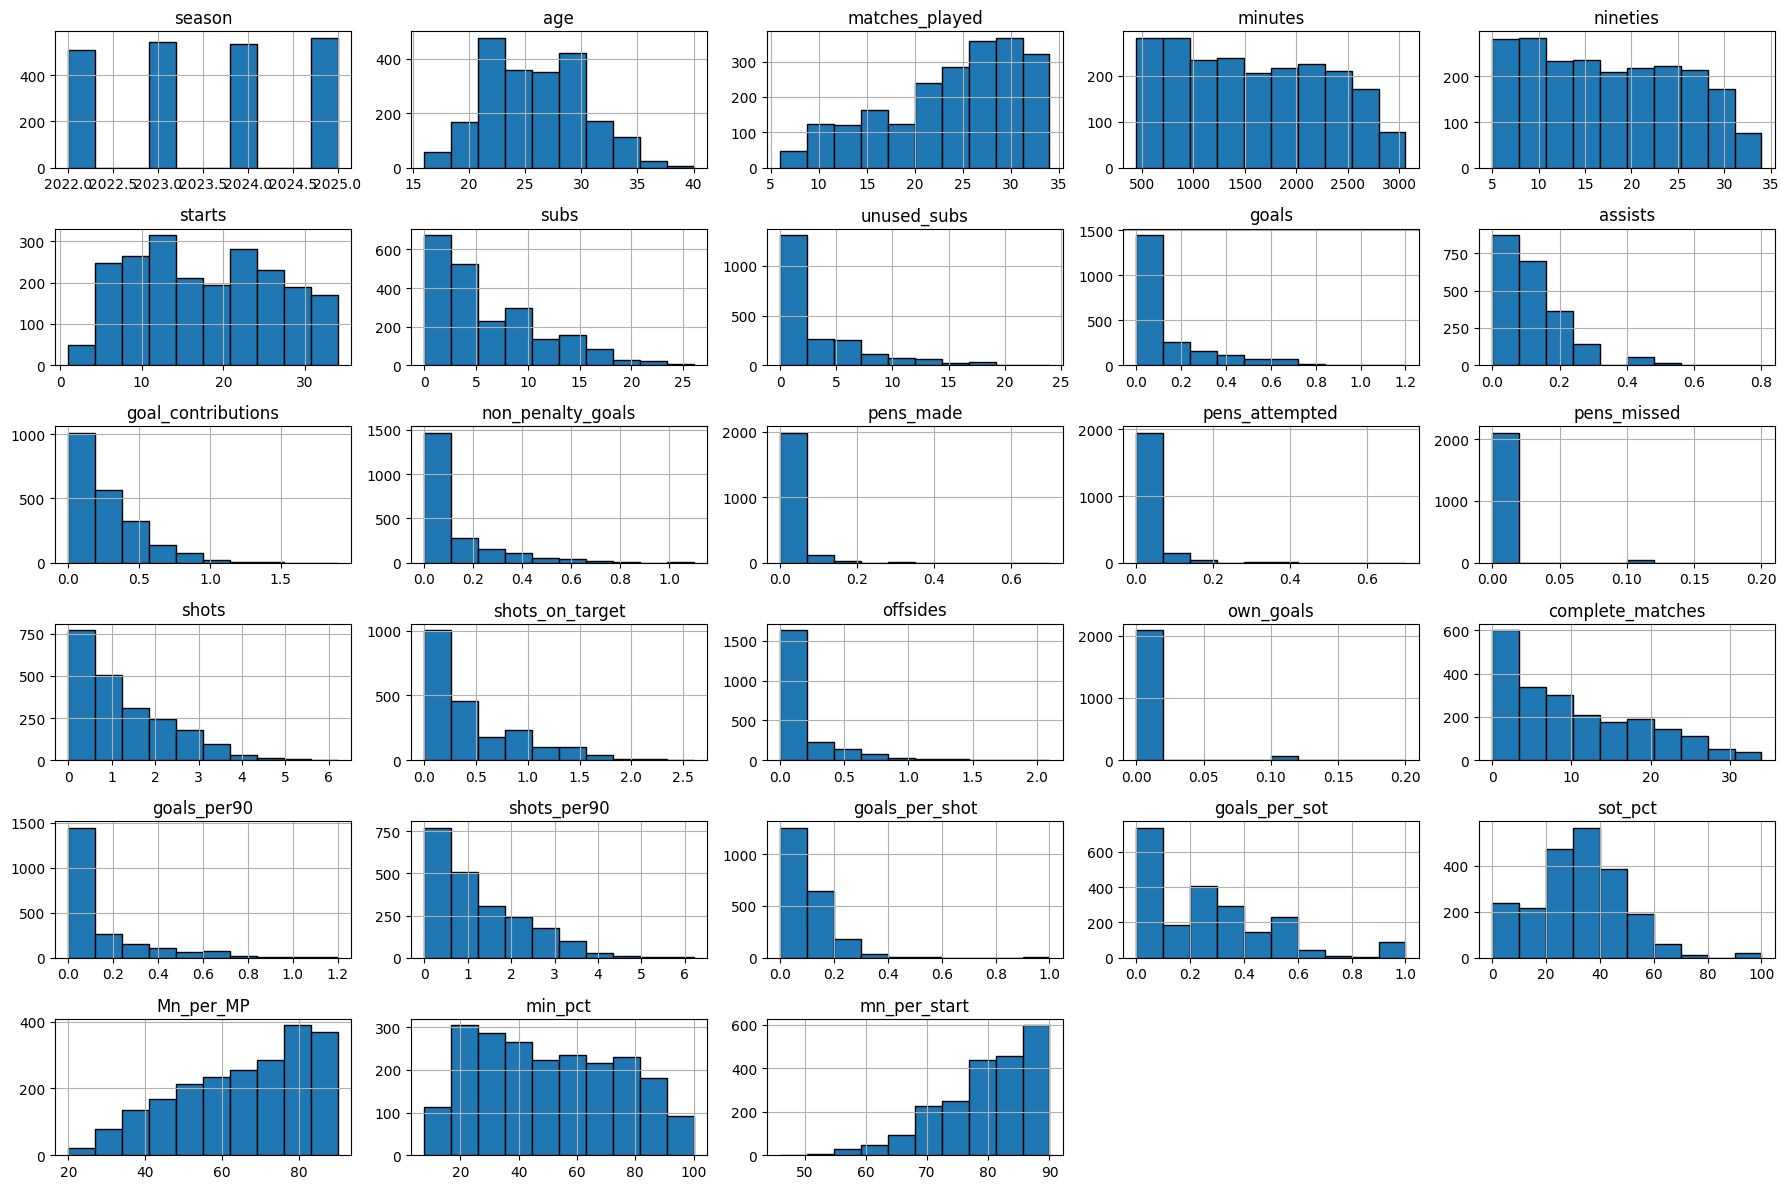

In [35]:

import matplotlib.pyplot as plt
model_df.hist(figsize=(18, 12), bins=10, edgecolor="black")
plt.tight_layout()
plt.show()

A histogram can give you a clue about which player stats seem to spread players out instead of bunching everyone together.

- If almost all players have very similar values, that stat may not help much.
- If some players clearly separate from the rest, that stat may be more informative
- If the shape looks strange, extreme, or noisy, that tells you to look closer before trusting it

But the key is this:
Separation alone is not enough.
A stat is useful when it shows separation that actually matches player style or role.

In [36]:
player_name = "Lionel Messi"

messi_rows = model_df[
    model_df["player"].str.strip().eq(player_name)
].copy()

# Check if Messi exists in the dataset
print("Number of Messi rows:", len(messi_rows))

# See every role your dataset gives him
print(messi_rows["role"].value_counts(dropna=False))

# View season-by-season role
messi_rows[["player", "season", "role", "goals", "assists", "shots_per90", "goals_per90", "minutes"]].sort_values("season")

Number of Messi rows: 2
role
striker    1
winger     1
Name: count, dtype: int64


,player,season,role,goals,assists,shots_per90,goals_per90,minutes
1378,Lionel Messi,2024,striker,1.2,0.7,5.1,1.2,1489
1379,Lionel Messi,2025,winger,1.1,0.6,5.8,1.1,2421


In [37]:
stat = "assists"

q75 = model_df[stat].quantile(0.75)
elite_pool = model_df[
    model_df[stat] >= q75
][["player","position", "season","role", stat]].sort_values(by=stat, ascending=False)

elite_pool.head(10)

,player,position,season,role,assists
1974,Saba Lobzhanidze,"MF,FW",2023,winger,0.8
1378,Lionel Messi,FW,2024,striker,0.7
653,Dylan Chambost,"MF,FW",2024,winger,0.7
1478,Maren Haile-Selassie,"MF,FW",2025,winger,0.6
1458,Marcel Hartel,MF,2024,central_midfielder,0.6
92,Ali Ahmed,"MF,FW",2025,winger,0.6
2268,Yamil Asad,MF,2024,central_midfielder,0.6
1379,Lionel Messi,"FW,MF",2025,winger,0.6
1907,Robin Lod,"MF,FW",2024,winger,0.5
2158,Thomas Müller,MF,2025,central_midfielder,0.5


In [38]:
stat = "goals"

q75 = model_df[stat].quantile(0.75)
elite_pool = model_df[
    model_df[stat] >= q75
][["player", "season","position", stat]].sort_values(by=stat, ascending=False)

elite_pool.head(10)

,player,season,position,goals
1378,Lionel Messi,2024,FW,1.2
2158,Thomas Müller,2025,MF,1.2
1379,Lionel Messi,2025,"FW,MF",1.1
229,Bernard Kamungo,2023,"MF,FW",1.1
1260,Karol Świderski,2024,FW,1.0
571,Dejan Joveljić,2022,"FW,MF",1.0
1620,Milan Iloski,2025,"MF,FW",1.0
2079,Son Heung-min,2025,FW,1.0
106,Alonso Martínez,2024,FW,1.0
1420,Luis Suárez,2024,FW,0.9


In [39]:
elite_pool["season"].value_counts().sort_index()

,count
season,
2022,160
2023,181
2024,191
2025,173


In [40]:
model_df[["goals_per_shot", "shots_per90", "assists","goals"]].corr(method="spearman")

,goals_per_shot,shots_per90,assists,goals
goals_per_shot,1.000000,0.356486,0.185085,0.777655
shots_per90,0.356486,1.000000,0.443801,0.747920
assists,0.185085,0.443801,1.000000,0.373761
goals,0.777655,0.747920,0.373761,1.000000


In [41]:
player_name = "Lionel Messi"
stats = ["role","goals", "assists", "shots_per90","goals_per90", "minutes"]

player_seasons = model_df[
    model_df["player"] == player_name
][["player", "season"] + stats].sort_values("season")

player_seasons

,player,season,role,goals,assists,shots_per90,goals_per90,minutes
1378,Lionel Messi,2024,striker,1.2,0.7,5.1,1.2,1489
1379,Lionel Messi,2025,winger,1.1,0.6,5.8,1.1,2421


Average assists: 0.1650510204081633
Minimum: 0.0
Maximum: 0.8


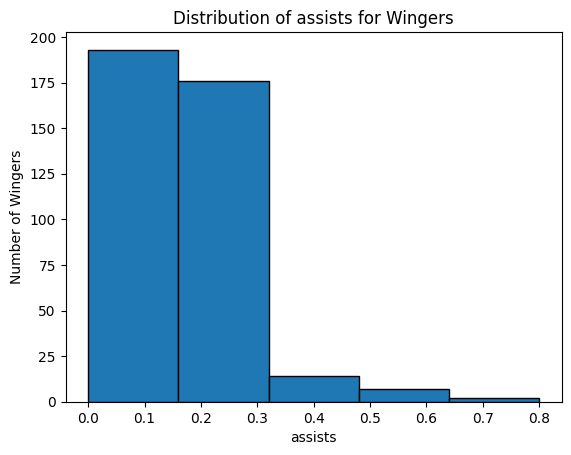

In [42]:
import matplotlib.pyplot as plt

# Keep only midfielders
midfielders = model_df[model_df["role"] == "winger"]

# Look at the continuous stat
stat = midfielders["assists"]

# Basic summary
avg_value = stat.mean()
min_value = stat.min()
max_value = stat.max()

print("Average assists:", avg_value)
print("Minimum:", min_value)
print("Maximum:", max_value)

# Histogram
plt.hist(stat, bins=5, edgecolor="black")
plt.xlabel("assists")
plt.ylabel("Number of Wingers")
plt.title("Distribution of assists for Wingers")
plt.show()

Before building the similarity model, these results suggest the data is already showing useful attacking patterns. The top assists list highlights players who create chances for others, while the top goals list highlights strong finishers. The season counts look fairly balanced across 2022 to 2025, which is a good sign because the model is not being driven too heavily by just one year.

The correlation table also gives a helpful preview. `goals_per_shot` has a strong relationship with `goals` (`0.78`), which suggests better finishing is strongly connected to actually scoring. `shots_per90` also has a strong relationship with `goals` (`0.75`), meaning players who shoot more often also tend to score more. `assists` has weaker relationships with goals and finishing, which makes sense because creating goals and scoring goals are related, but not the exact same skill.

This histogram shows that most wingers do not get many assists, while a few get a lot. So assists is useful for spotting standout creators, but it should be combined with other features so the model does not over-focus on a small number of extreme players.

Since only a small number of wingers have very high assists, this stat can make those players stand out a lot more than the rest. That means you should not let this one feature unfairly overpower your whole similarity model.

Overall, this is a good sign going into the similarity model because the features already seem to capture real differences in player style and production.

In [43]:
# role-specific feature weights

ROLE_WEIGHTS = {
    "center_back": {
        "nineties": 1.0, "minutes": 1.0, "min_pct": 1.2, "starts": 1.2, "mn_per_start": 1.0, "complete_matches": 1.2
    },
    "full_back": {
        "nineties": 0.8, "minutes": 0.8, "min_pct": 1.0, "starts": 1.0, "assists": 1.2, "goal_contributions": 1.0, "team_goal_share": 0.8
    },
    "central_midfielder": {
        "nineties": 0.8, "minutes": 0.8, "min_pct": 1.0, "starts": 1.0, "assists": 1.1, "goal_contributions": 1.0, "shots_per90": 0.9, "team_goal_share": 0.8
    },
    "winger": {
        "goals_per90": 1.2, "shots_per90": 1.1, "shots_on_target": 1.0, "sot_pct": 0.9,
        "assists": 1.1, "goal_contributions": 1.2, "offsides_per90": 0.8, "minutes": 0.7, "team_goal_share": 0.8
    },
    "striker": {
        "goals_per90": 1.5, "non_penalty_goals": 1.2, "shots_per90": 1.2, "goals_per_shot": 1.1,
        "goals_per_sot": 1.0, "shots_on_target": 1.0, "sot_pct": 0.9, "offsides_per90": 0.8,
        "pens_attempted": 0.5, "minutes": 0.7, "team_goal_share": 0.8
    }
}

In [44]:
#apply basic recruitment filters

def apply_filters(df, min_age=None, max_age=None, min_minutes=600, competitions=None):
    out = df.copy()

    if min_age is not None:
        out = out[out["age"] >= min_age]

    if max_age is not None:
        out = out[out["age"] <= max_age]

    if min_minutes is not None:
        out = out[out["minutes"] >= min_minutes]

    if competitions is not None:
        out = out[out["competition"].isin(competitions)]

    return out

In [45]:
# standardize features within role

from sklearn.preprocessing import StandardScaler

def scale_within_role(df, role, feature_cols):
    role_df = df[df["role"] == role].copy()

    use_cols = [col for col in feature_cols if col in role_df.columns]

    X = role_df[use_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    z_cols = []
    for i, col in enumerate(use_cols):
        z_col = f"{col}_z"
        role_df[z_col] = X_scaled[:, i]
        z_cols.append(z_col)

    return role_df, use_cols, z_cols

In [46]:
# weighted cosine similarity

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def weighted_similarity_scores(role_df, target_row_id, raw_feature_cols, z_feature_cols, feature_weights):
    X = role_df[z_feature_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    weights = np.array([feature_weights.get(col, 1.0) for col in raw_feature_cols], dtype=float)
    X_weighted = X * np.sqrt(weights)

    target_idx = role_df.index[role_df["row_id"] == target_row_id][0]
    target_vector = X_weighted.loc[[target_idx]]

    sims = cosine_similarity(target_vector, X_weighted)[0]

    out = role_df.copy()
    out["similarity_score"] = sims

    return out.sort_values("similarity_score", ascending=False)

This part of the code prepares the player stats so they can be compared fairly within each role group. It first looks at one role at a time, like wingers or center backs, then fills in missing values and standardizes the stats so they are all on the same scale. In simple terms, this prevents a big number like minutes played from overpowering a smaller number like goals per 90, and it makes each stat easier to compare fairly across players in the same role.

The next part is where the model actually measures player similarity. It gives more importance to the stats chosen as most meaningful for that role, then compares the target player’s profile to every other player in that role and gives each one a similarity score. Yes, this is the main **role-based nearest neighbors** part of the project, because it is the step that finds which players look most similar to the target player based on their role-specific stat pattern.

In [47]:
#  end-to-end player similarity search

def pick_target_row_id(df, player_name, season=None, role=None):
    matches = df[df["player"] == player_name].copy()

    if season is not None:
        matches = matches[matches["season"] == season]
    if role is not None:
        matches = matches[matches["role"] == role]

    if matches.empty:
        raise ValueError(f"No matching row found for player '{player_name}' with season={season} and role={role}.")

    # Sort by minutes as a tie-breaker or default if season/role don't fully disambiguate
    matches = matches.sort_values("minutes", ascending=False)
    return matches["row_id"].iloc[0]

def find_role_matches(df, target_player, min_age=None, max_age=None, min_minutes=600, competitions=None):
    filtered = apply_filters(df, min_age=min_age, max_age=max_age, min_minutes=min_minutes, competitions=competitions)

    target_row_id = pick_target_row_id(df, target_player)
    target_role = df.loc[df["row_id"] == target_row_id, "role"].iloc[0]

    role_df, raw_cols, z_cols = scale_within_role(filtered, target_role, ROLE_FEATURES[target_role])

    if target_row_id not in role_df["row_id"].values:
        target_row = df[df["row_id"] == target_row_id].copy()
        role_df = pd.concat([role_df, target_row], ignore_index=True)
        role_df, raw_cols, z_cols = scale_within_role(role_df, target_role, ROLE_FEATURES[target_role])

    scored = weighted_similarity_scores(
        role_df=role_df,
        target_row_id=target_row_id,
        raw_feature_cols=raw_cols,
        z_feature_cols=z_cols,
        feature_weights=ROLE_WEIGHTS[target_role]
    )

    scored = scored[scored["row_id"] != target_row_id].copy()

    return scored

In [48]:
#test one target player

TARGET_PLAYER = "Lionel Messi"   # replace if needed

top_matches = find_role_matches(
    model_df,
    target_player=TARGET_PLAYER,
    min_age=18,
    max_age=35,
    min_minutes=600,
    competitions=None
)

display(top_matches[[
    "player", "team", "competition", "season", "role",
    "age", "minutes", "goals_per90", "assists", "shots_per90", "similarity_score"
]].head(10))


,player,team,competition,season,role,age,minutes,goals_per90,assists,shots_per90,similarity_score
227,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2023,winger,30,1702,0.5,0.3,3.5,0.987831
322,Tani Oluwaseyi,Minnesota Utd,us Major League Soccer,2025,winger,24,1856,0.5,0.3,3.0,0.982113
256,Milan Iloski,2 Teams,us Major League Soccer,2025,winger,25,1074,1.0,0.4,5.3,0.975141
240,Martín Ojeda,Orlando City,us Major League Soccer,2025,winger,26,2680,0.5,0.3,3.5,0.957318
143,Gustavo Bou,NE Revolution,us Major League Soccer,2023,winger,32,1263,0.5,0.3,3.9,0.954877
226,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2022,winger,29,2316,0.4,0.3,3.1,0.951846
168,Jefferson Savarino,Real Salt Lake,us Major League Soccer,2022,winger,25,1522,0.4,0.2,3.2,0.950952
131,Gabriel Chaves,LA Galaxy,us Major League Soccer,2024,winger,22,2727,0.5,0.4,4.1,0.946696
189,Joseph Paintsil,LA Galaxy,us Major League Soccer,2024,winger,25,2294,0.4,0.3,2.9,0.946658
146,Hany Mukhtar,Nashville SC,us Major League Soccer,2023,winger,27,2835,0.5,0.3,3.7,0.942760


In [49]:
# keep only one row per player in final match output

top_matches_unique = (
    top_matches.sort_values("similarity_score", ascending=False)
    .drop_duplicates(subset=["row_id"], keep="first")
    .reset_index(drop=True)
)

display(top_matches_unique[[
    "player", "team", "competition", "season", "role",
    "age", "minutes", "goals_per90", "assists", "shots_per90", "similarity_score"
]].head(10))

,player,team,competition,season,role,age,minutes,goals_per90,assists,shots_per90,similarity_score
0,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2023,winger,30,1702,0.5,0.3,3.5,0.987831
1,Tani Oluwaseyi,Minnesota Utd,us Major League Soccer,2025,winger,24,1856,0.5,0.3,3.0,0.982113
2,Milan Iloski,2 Teams,us Major League Soccer,2025,winger,25,1074,1.0,0.4,5.3,0.975141
3,Martín Ojeda,Orlando City,us Major League Soccer,2025,winger,26,2680,0.5,0.3,3.5,0.957318
4,Gustavo Bou,NE Revolution,us Major League Soccer,2023,winger,32,1263,0.5,0.3,3.9,0.954877
5,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2022,winger,29,2316,0.4,0.3,3.1,0.951846
6,Jefferson Savarino,Real Salt Lake,us Major League Soccer,2022,winger,25,1522,0.4,0.2,3.2,0.950952
7,Gabriel Chaves,LA Galaxy,us Major League Soccer,2024,winger,22,2727,0.5,0.4,4.1,0.946696
8,Joseph Paintsil,LA Galaxy,us Major League Soccer,2024,winger,25,2294,0.4,0.3,2.9,0.946658
9,Hany Mukhtar,Nashville SC,us Major League Soccer,2023,winger,27,2835,0.5,0.3,3.7,0.942760


**top_matches** is the **full version** of the results, so it can show the same player more than once if that player appears in different seasons or records. This is useful when you want to study every possible match in detail. **top_matches_unique** is the **cleaned version**, where only one best row is kept for each player or unique record, depending on the rule you used. In simple terms, use `top_matches` when you want the full picture, and use `top_matches_unique` when you want a shorter, cleaner scouting list that is easier to present and understand.

These columns in the datafram, help explain **who the player is and why the model matched them** to the target player. `player`, `team`, `competition`, and `season` tell you which exact player record you are looking at. `role` shows the type of player being compared, so a **winger** is being matched to other **wingers** instead of **defenders** or **strikers**. `age` helps you judge whether the player fits your recruitment timeline, and `minutes` shows how much real playing time the player had, which matters because stats from players with more minutes are usually more trustworthy. `goals_per90`, `assists`, and `shots_per90` help describe attacking style in simple terms: how often the player scores, helps create goals, and shoots when they are on the field. `similarity_score` is the most important output because it shows how close that player’s overall profile is to the **target player**. The closer the score is to **1**, the more similar the player looks in this model.

In [50]:
#create useful recruiting slices

target_age = model_df.loc[model_df["player"] == TARGET_PLAYER, "age"].max()

younger_alts = top_matches[top_matches["age"] < target_age].head(10)
upside_bets = top_matches[(top_matches["minutes"] >= 300) & (top_matches["minutes"] < 1200)].head(10)

print("Younger alternatives")
display(younger_alts[["player", "team", "age", "minutes", "similarity_score"]])

print("Lower-minute upside bets")
display(upside_bets[["player", "team", "age", "minutes", "similarity_score"]])

Younger alternatives


,player,team,age,minutes,similarity_score
227,Lucas Zelarayán,Columbus Crew,30,1702,0.987831
322,Tani Oluwaseyi,Minnesota Utd,24,1856,0.982113
256,Milan Iloski,2 Teams,25,1074,0.975141
240,Martín Ojeda,Orlando City,26,2680,0.957318
143,Gustavo Bou,NE Revolution,32,1263,0.954877
226,Lucas Zelarayán,Columbus Crew,29,2316,0.951846
168,Jefferson Savarino,Real Salt Lake,25,1522,0.950952
131,Gabriel Chaves,LA Galaxy,22,2727,0.946696
189,Joseph Paintsil,LA Galaxy,25,2294,0.946658
146,Hany Mukhtar,Nashville SC,27,2835,0.942760


Lower-minute upside bets


,player,team,age,minutes,similarity_score
256,Milan Iloski,2 Teams,25,1074,0.975141
82,Dejan Joveljić,LA Galaxy,22,1003,0.886747
219,Lorenzo Insigne,Toronto FC,30,926,0.868506
47,Cedric Teuchert,St. Louis City,27,754,0.865271
316,Stephen Afrifa,Sporting KC,22,795,0.812244
90,Diego Rossi,Columbus Crew,24,770,0.792810
16,Amahl Pellegrino,2 Teams,34,816,0.721298
350,Yordy Reyna,Charlotte,28,845,0.713143
328,Theodore Ku-Dipietro,D.C. United,21,1167,0.705018
335,Tomás Chancalay,NE Revolution,26,1175,0.666903


I included recruiting slices to make the similarity results more useful for real scouting decisions. The main match lists show which players are most statistically similar to the target player, while the recruiting slices help break those matches into more practical groups, such as younger alternatives or lower-minute players with upside. This makes the results easier to use when thinking about fit, age, and potential.

In simple terms, the full similarity list answers **“who looks most like this player,”** while the recruiting slices help answer **“which similar players may be better long-term options”** or **“which similar players may still have room to grow.”** This was included to make the model more helpful for recruitment, not just comparison.

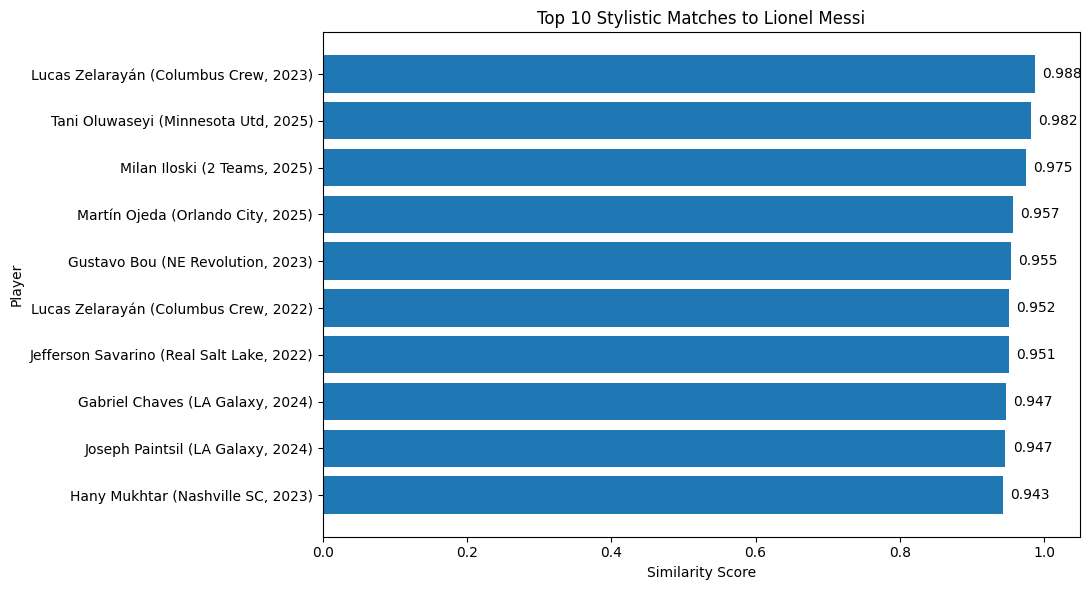

In [51]:
#  visual

import matplotlib.pyplot as plt

plot_df = (
    top_matches_unique.head(10).copy()
    .sort_values("similarity_score", ascending=True)
)

plot_df["label"] = (
    plot_df["player"] + " (" +
    plot_df["team"] + ", " +
    plot_df["season"].astype(str) + ")"
)

plt.figure(figsize=(11, 6))
bars = plt.barh(plot_df["label"], plot_df["similarity_score"])

plt.title("Top 10 Stylistic Matches to Lionel Messi")
plt.xlabel("Similarity Score")
plt.ylabel("Player")
plt.xlim(0, 1.05)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}", va="center")

plt.tight_layout()
plt.show()

##Bayesian-inspired uncertainty adjustment

In [52]:
#  simple empirical Bayes style shrinkage

import numpy as np
import pandas as pd

def shrink_rate(value, denom, group_mean, prior_strength):
    # Return NaN if the value is missing
    if pd.isna(value):
        return np.nan

    # Clean denominator
    if pd.isna(denom):
        denom = 0

    denom = max(denom, 0)

    # Shrinkage weight
    weight = denom / (denom + prior_strength)

    # Blend player stat with role average
    return (weight * value) + ((1 - weight) * group_mean)

In [53]:
#apply shrinkage within each role

def apply_role_shrinkage(df):
    out = df.copy()

    # metric -> (denominator column, prior strength)
    metric_map = {
        "goals_per90": ("nineties", 8.0),
        "shots_per90": ("nineties", 8.0),
        "offsides_per90": ("nineties", 8.0),
        "goals_per_shot": ("shots", 30.0),
        "goals_per_sot": ("shots_on_target", 15.0),
        "sot_pct": ("shots", 30.0)
    }

    for role, group in out.groupby("role"):
        for metric, (denom_col, prior_strength) in metric_map.items():
            if metric in out.columns and denom_col in out.columns:
                role_mean = group[metric].mean()

                out.loc[group.index, f"{metric}_adj"] = group.apply(
                    lambda row: shrink_rate(
                        value=row[metric],
                        denom=row[denom_col],
                        group_mean=role_mean,
                        prior_strength=prior_strength
                    ),
                    axis=1
                )

    return out

model_df = apply_role_shrinkage(model_df)

# Quick check
display(model_df[[
    "player", "role", "minutes", "goals_per90", "goals_per90_adj",
    "shots_per90", "shots_per90_adj"
]].head(10))

,player,role,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj
0,Aaron Boupendza,striker,606,0.7,0.551320,4.2,3.415673
1,Aaron Boupendza,winger,553,0.3,0.275973,2.9,2.490245
2,Aaron Herrera,center_back,2268,0.0,0.009148,0.6,0.575755
3,Aaron Herrera,full_back,1407,0.0,0.017593,0.3,0.448180
4,Aaron Herrera,full_back,2594,0.0,0.011282,1.1,1.021115
5,Aaron Herrera,full_back,2066,0.0,0.013393,0.7,0.709582
6,Aaron Long,center_back,2366,0.2,0.162207,0.7,0.653209
7,Aaron Long,center_back,1519,0.0,0.012197,0.5,0.499802
8,Aaron Long,center_back,2374,0.0,0.008829,0.3,0.346368
9,Aaron Long,center_back,1271,0.1,0.077543,0.3,0.372175


In [54]:
#  adjusted similarity search using Bayes-shrunk stats when possible

def find_role_matches_adjusted(df, target_player, min_age=None, max_age=None, min_minutes=600, competitions=None, target_season=None, target_role=None):
    filtered = apply_filters(df, min_age=min_age, max_age=max_age, min_minutes=min_minutes, competitions=competitions)

    target_row_id = pick_target_row_id(df, target_player, season=target_season, role=target_role)
    target_role = df.loc[df["row_id"] == target_row_id, "role"].iloc[0]

    raw_features = ROLE_FEATURES[target_role]

    # Prefer adjusted versions if they exist
    adjusted_features = []
    for col in raw_features:
        if f"{col}_adj" in filtered.columns:
            adjusted_features.append(f"{col}_adj")
        else:
            adjusted_features.append(col)

    role_df, raw_cols_used, z_cols = scale_within_role(filtered, target_role, adjusted_features)

    if target_row_id not in role_df["row_id"].values:
        target_row_ = df[df["row_id"] == target_row_id].copy() # Renamed to avoid conflict
        role_df = pd.concat([role_df, target_row_], ignore_index=True)
        role_df, raw_cols_used, z_cols = scale_within_role(role_df, target_role, ROLE_FEATURES[target_role])

    # Map weights back to original feature names
    adjusted_weights = {}
    for col in raw_cols_used:
        base_col = col.replace("_adj", "")
        adjusted_weights[col] = ROLE_WEIGHTS[target_role].get(base_col, 1.0)

    scored = weighted_similarity_scores(
        role_df=role_df,
        target_row_id=target_row_id,
        raw_feature_cols=raw_cols_used,
        z_feature_cols=z_cols,
        feature_weights=adjusted_weights
    )

    scored = scored[scored["row_id"] != target_row_id].copy()

    return scored


In [55]:
# adjusted similarity search using Bayes-shrunk stats when possible

def find_role_matches_adjusted(df, target_player, min_age=None, max_age=None, min_minutes=600, competitions=None, target_season=None, target_role=None):
    filtered = apply_filters(df, min_age=min_age, max_age=max_age, min_minutes=min_minutes, competitions=competitions)

    target_row_id = pick_target_row_id(df, target_player, season=target_season, role=target_role)
    target_role = df.loc[df["row_id"] == target_row_id, "role"].iloc[0]

    raw_features = ROLE_FEATURES[target_role]

    # Prefer adjusted versions if they exist
    adjusted_features = []
    for col in raw_features:
        if f"{col}_adj" in filtered.columns:
            adjusted_features.append(f"{col}_adj")
        else:
            adjusted_features.append(col)

    role_df, raw_cols_used, z_cols = scale_within_role(filtered, target_role, adjusted_features)

    if target_row_id not in role_df["row_id"].values:
        target_row_ = df[df["row_id"] == target_row_id].copy()
        role_df = pd.concat([role_df, target_row_], ignore_index=True)
        role_df, raw_cols_used, z_cols = scale_within_role(role_df, target_role, adjusted_features)

    # Map weights back to original feature names
    adjusted_weights = {}
    for col in raw_cols_used:
        base_col = col.replace("_adj", "")
        adjusted_weights[col] = ROLE_WEIGHTS[target_role].get(base_col, 1.0)

    scored = weighted_similarity_scores(
        role_df=role_df,
        target_row_id=target_row_id,
        raw_feature_cols=raw_cols_used,
        z_feature_cols=z_cols,
        feature_weights=adjusted_weights
    )

    scored = scored[scored["row_id"] != target_row_id].copy()

    return scored

In [56]:
# compare raw vs adjusted model output for Messi as striker and winger


TARGET_PLAYER = "Lionel Messi"

target_versions = [
    {"TARGET_SEASON": 2024, "TARGET_ROLE": "striker"},
    {"TARGET_SEASON": 2025, "TARGET_ROLE": "winger"}
]

for target_version in target_versions:
    TARGET_SEASON = target_version["TARGET_SEASON"]
    TARGET_ROLE = target_version["TARGET_ROLE"]

    # Keep everyone else, but keep only the Messi row we want
    model_df_target = model_df[
        (model_df["player"] != TARGET_PLAYER) |
        (
            (model_df["player"] == TARGET_PLAYER) &
            (model_df["season"] == TARGET_SEASON) &
            (model_df["role"] == TARGET_ROLE)
        )
    ].copy()

    print("=" * 80)
    print(f"TARGET PLAYER: {TARGET_PLAYER}")
    print(f"TARGET SEASON: {TARGET_SEASON}")
    print(f"TARGET ROLE: {TARGET_ROLE}")
    print("=" * 80)

    print("Target row being used")
    display(
        model_df_target[
            model_df_target["player"] == TARGET_PLAYER
        ][[
            "player", "team", "season", "position", "role",
            "minutes", "goals_per90", "shots_per90"
        ]]
    )

    raw_matches = find_role_matches(
        model_df_target,
        target_player=TARGET_PLAYER,
        min_age=18,
        max_age=35,
        min_minutes=600,
        competitions=None
    )

    adj_matches = find_role_matches_adjusted(
        model_df,
        target_player=TARGET_PLAYER,
        min_age=18,
        max_age=35,
        min_minutes=600,
        competitions=None,
        target_season=TARGET_SEASON,
        target_role=TARGET_ROLE
    )

    print("Raw similarity results")
    display(raw_matches[[
        "player", "team", "season", "role",
        "minutes", "goals_per90", "shots_per90", "similarity_score"
    ]].head(10))

    print("Bayes-adjusted similarity results")
    display(adj_matches[[
        "player", "team", "season", "role",
        "minutes", "goals_per90", "goals_per90_adj",
        "shots_per90", "shots_per90_adj",
        "similarity_score"
    ]].head(10))

TARGET PLAYER: Lionel Messi
TARGET SEASON: 2024
TARGET ROLE: striker
Target row being used


,player,team,season,position,role,minutes,goals_per90,shots_per90
1378,Lionel Messi,Inter Miami,2024,FW,striker,1489,1.2,5.1


Raw similarity results


,player,team,season,role,minutes,goals_per90,shots_per90,similarity_score
185,Raúl Ruidíaz,Seattle Sounders,2022,striker,1302,0.6,3.5,0.969150
203,Son Heung-min,LAFC,2025,striker,803,1.0,3.9,0.949290
1,Adam Buksa,NE Revolution,2022,striker,815,0.8,3.9,0.941565
219,William Agada,Sporting KC,2022,striker,918,0.8,4.0,0.940129
211,Teemu Pukki,Minnesota Utd,2023,striker,1031,0.9,3.4,0.939091
111,Josef Martínez,Atlanta Utd,2022,striker,1465,0.6,3.0,0.922840
205,Tai Baribo,Philadelphia Union,2024,striker,1409,0.6,3.2,0.918493
9,Anderson Julio,Real Salt Lake,2024,striker,1394,0.6,3.5,0.896219
83,Giorgos Giakoumakis,Atlanta Utd,2023,striker,1781,0.9,3.3,0.890101
76,Felipe Mora,Portland Timbers,2024,striker,1889,0.7,3.1,0.889614


Bayes-adjusted similarity results


...

,player,team,season,position,role,minutes,goals_per90,shots_per90
1379,Lionel Messi,Inter Miami,2025,"FW,MF",winger,2421,1.1,5.8


Raw similarity results


,player,team,season,role,minutes,goals_per90,shots_per90,similarity_score
227,Lucas Zelarayán,Columbus Crew,2023,winger,1702,0.5,3.5,0.987831
322,Tani Oluwaseyi,Minnesota Utd,2025,winger,1856,0.5,3.0,0.982113
256,Milan Iloski,2 Teams,2025,winger,1074,1.0,5.3,0.975141
240,Martín Ojeda,Orlando City,2025,winger,2680,0.5,3.5,0.957318
143,Gustavo Bou,NE Revolution,2023,winger,1263,0.5,3.9,0.954877
226,Lucas Zelarayán,Columbus Crew,2022,winger,2316,0.4,3.1,0.951846
168,Jefferson Savarino,Real Salt Lake,2022,winger,1522,0.4,3.2,0.950952
131,Gabriel Chaves,LA Galaxy,2024,winger,2727,0.5,4.1,0.946696
189,Joseph Paintsil,LA Galaxy,2024,winger,2294,0.4,2.9,0.946658
146,Hany Mukhtar,Nashville SC,2023,winger,2835,0.5,3.7,0.942760


Bayes-adjusted similarity results


,player,team,season,role,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,similarity_score
322,Tani Oluwaseyi,Minnesota Utd,2025,winger,1856,0.5,0.432211,3.0,2.770016,0.978529
256,Milan Iloski,2 Teams,2025,winger,1074,1.0,0.701569,5.3,4.044847,0.971856
227,Lucas Zelarayán,Columbus Crew,2023,winger,1702,0.5,0.427927,3.5,3.106782,0.969117
240,Martín Ojeda,Orlando City,2025,winger,2680,0.5,0.448710,3.5,3.220171,0.955993
226,Lucas Zelarayán,Columbus Crew,2022,winger,2316,0.4,0.366208,3.1,2.881082,0.952014
189,Joseph Paintsil,LA Galaxy,2024,winger,2294,0.4,0.366007,2.9,2.727536,0.949524
168,Jefferson Savarino,Real Salt Lake,2022,winger,1522,0.4,0.354266,3.2,2.871584,0.948554
146,Hany Mukhtar,Nashville SC,2023,winger,2835,0.5,0.450917,3.7,3.391708,0.948463
93,Diego Rubio,Colorado Rapids,2022,winger,2436,0.6,0.521972,3.4,3.121437,0.944410
131,Gabriel Chaves,LA Galaxy,2024,winger,2727,0.5,0.449379,4.1,3.698497,0.942492


This part of the project adds a stability check to the similarity model. It slightly pulls extreme rate stats, like goals per 90 or shots per 90, back toward the average for that player’s role when the player has a smaller sample size. In simple terms, it helps prevent the model from overreacting to players whose numbers may look unusually high or low because they did not play enough minutes or take enough shots.

This is useful as a comparison tool, not necessarily the main version of the model. The raw results show the direct similarity matches, while the adjusted results show a more cautious version that tries to reduce small-sample noise.  The raw model is the main scouting output, and the adjusted model is an added check to see whether the top matches still look strong after making the stats more stable.

In [57]:
# create uncertainty score and Low/Medium/High band

def add_uncertainty_fields(df):
    out = df.copy()

    # More minutes = lower uncertainty
    out["unc_minutes"] = 1 - np.clip(out["minutes"] / 1800, 0, 1)

    # More shots = lower uncertainty for finishing metrics
    if "shots" in out.columns:
        out["unc_shots"] = 1 - np.clip(out["shots"] / 50, 0, 1)
    else:
        out["unc_shots"] = 1.0

    # More starts = lower uncertainty
    if "starts" in out.columns and "matches_played" in out.columns:
        out["start_rate"] = np.where(out["matches_played"] > 0, out["starts"] / out["matches_played"], np.nan)
        out["unc_starts"] = 1 - np.clip(out["start_rate"] / 0.8, 0, 1)
    else:
        out["unc_starts"] = 1.0

    # Optional position mismatch penalty if that column exists
    if "position_mismatch_flag" in out.columns:
        out["unc_position"] = np.where(out["position_mismatch_flag"], 0.20, 0.00)
    else:
        out["unc_position"] = 0.00

    # Combine into one score
    out["uncertainty_score"] = (
        0.45 * out["unc_minutes"].fillna(1.0) +
        0.25 * out["unc_shots"].fillna(1.0) +
        0.20 * out["unc_starts"].fillna(1.0) +
        0.10 * out["unc_position"].fillna(0.0)
    )

    # Turn score into a label
    out["uncertainty_band"] = pd.cut(
        out["uncertainty_score"],
        bins=[-np.inf, 0.33, 0.66, np.inf],
        labels=["Low", "Medium", "High"]
    )

    return out

model_df = add_uncertainty_fields(model_df)

display(model_df[[
    "player", "role", "minutes", "shots",
    "uncertainty_score", "uncertainty_band"
]].head(10))

,player,role,minutes,shots,uncertainty_score,uncertainty_band
0,Aaron Boupendza,striker,606,4.2,0.577500,Medium
1,Aaron Boupendza,winger,553,2.9,0.657964,Medium
2,Aaron Herrera,center_back,2268,0.6,0.247000,Low
3,Aaron Herrera,full_back,1407,0.3,0.346750,Medium
4,Aaron Herrera,full_back,2594,1.1,0.244500,Low
5,Aaron Herrera,full_back,2066,0.7,0.246500,Low
6,Aaron Long,center_back,2366,0.7,0.246500,Low
7,Aaron Long,center_back,1519,0.5,0.317750,Low
8,Aaron Long,center_back,2374,0.3,0.248500,Low
9,Aaron Long,center_back,1271,0.3,0.380750,Medium


In [58]:
#  Bayes-adjusted matches with uncertainty shown ie..another player-Carles Gil

# Bayes-adjusted matches with uncertainty shown
# Compare Lionel Messi as striker and winger

TARGET_PLAYER = "Lionel Messi"

target_versions = [
    {"TARGET_SEASON": 2024, "TARGET_ROLE": "striker"},
    {"TARGET_SEASON": 2025, "TARGET_ROLE": "winger"}
]

display_cols = [
    "player", "team", "competition", "season", "role",
    "age", "minutes",
    "goals_per90", "goals_per90_adj",
    "shots_per90", "shots_per90_adj",
    "uncertainty_score", "uncertainty_band",
    "similarity_score"
]

for target_version in target_versions:
    TARGET_SEASON = target_version["TARGET_SEASON"]
    TARGET_ROLE = target_version["TARGET_ROLE"]

    print("=" * 100)
    print(f"TARGET PLAYER: {TARGET_PLAYER}")
    print(f"TARGET SEASON: {TARGET_SEASON}")
    print(f"TARGET ROLE: {TARGET_ROLE}")
    print("=" * 100)

    print("Target row being used:")
    display(
        model_df[
            (model_df["player"] == TARGET_PLAYER) &
            (model_df["season"] == TARGET_SEASON) &
            (model_df["role"] == TARGET_ROLE)
        ][[
            "player", "team", "competition", "season", "position", "role",
            "age", "minutes",
            "goals_per90", "goals_per90_adj",
            "shots_per90", "shots_per90_adj",
            "uncertainty_score", "uncertainty_band"
        ]]
    )

    adj_matches = find_role_matches_adjusted(
        model_df,
        target_player=TARGET_PLAYER,
        min_age=18,
        max_age=35,
        min_minutes=600,
        competitions=None,
        target_season=TARGET_SEASON,
        target_role=TARGET_ROLE
    )

    print("Bayes-adjusted similarity results:")
    display(adj_matches[display_cols].head(10))


TARGET PLAYER: Lionel Messi
TARGET SEASON: 2024
TARGET ROLE: striker
Target row being used:


,player,team,competition,season,position,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_score,uncertainty_band
1378,Lionel Messi,Inter Miami,us Major League Soccer,2024,FW,striker,36,1489,1.2,0.947527,5.1,4.335527,0.304882,Low


Bayes-adjusted similarity results:


,player,team,competition,season,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_score,uncertainty_band,similarity_score
185,Raúl Ruidíaz,Seattle Sounders,us Major League Soccer,2022,striker,31,1302,0.6,0.538418,3.5,3.236462,0.362556,Medium,0.949692
211,Teemu Pukki,Minnesota Utd,us Major League Soccer,2023,striker,32,1031,0.9,0.705867,3.4,3.136944,0.425250,Medium,0.946863
205,Tai Baribo,Philadelphia Union,us Major League Soccer,2024,striker,26,1409,0.6,0.541536,3.2,3.051072,0.331750,Medium,0.938482
203,Son Heung-min,LAFC,us Major League Soccer,2025,striker,32,803,1.0,0.728663,3.9,3.359787,0.479750,Medium,0.936056
111,Josef Martínez,Atlanta Utd,us Major League Soccer,2022,striker,28,1465,0.6,0.542979,3.0,2.920593,0.403365,Medium,0.932730
1,Adam Buksa,NE Revolution,us Major League Soccer,2022,striker,25,815,0.8,0.625404,3.9,3.366105,0.476750,Medium,0.927871
76,Felipe Mora,Portland Timbers,us Major League Soccer,2024,striker,30,1889,0.7,0.624634,3.1,3.005876,0.244845,Low,0.925493
46,Daniel Musovski,Seattle Sounders,us Major League Soccer,2025,striker,29,1562,0.8,0.682457,3.1,2.992535,0.364968,Medium,0.921030
83,Giorgos Giakoumakis,Atlanta Utd,us Major League Soccer,2023,striker,28,1781,0.9,0.763827,3.3,3.144259,0.243806,Low,0.918611
18,Brenner,FC Cincinnati,us Major League Soccer,2022,striker,22,2056,0.8,0.703065,3.3,3.159429,0.243845,Low,0.916168


TARGET PLAYER: Lionel Messi
TARGET SEASON: 2025
TARGET ROLE: winger
Target row being used:


,player,team,competition,season,position,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_score,uncertainty_band
1379,Lionel Messi,Inter Miami,us Major League Soccer,2025,"FW,MF",winger,37,2421,1.1,0.906912,5.8,4.969698,0.221,Low


Bayes-adjusted similarity results:


,player,team,competition,season,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_score,uncertainty_band,similarity_score
322,Tani Oluwaseyi,Minnesota Utd,us Major League Soccer,2025,winger,24,1856,0.5,0.432211,3.0,2.770016,0.235000,Low,0.978529
256,Milan Iloski,2 Teams,us Major League Soccer,2025,winger,25,1074,1.0,0.701569,5.3,4.044847,0.496304,Medium,0.971856
227,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2023,winger,30,1702,0.5,0.427927,3.5,3.106782,0.257000,Low,0.969117
240,Martín Ojeda,Orlando City,us Major League Soccer,2025,winger,26,2680,0.5,0.448710,3.5,3.220171,0.232500,Low,0.955993
226,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2022,winger,29,2316,0.4,0.366208,3.1,2.881082,0.234500,Low,0.952014
189,Joseph Paintsil,LA Galaxy,us Major League Soccer,2024,winger,25,2294,0.4,0.366007,2.9,2.727536,0.235500,Low,0.949524
168,Jefferson Savarino,Real Salt Lake,us Major League Soccer,2022,winger,25,1522,0.4,0.354266,3.2,2.871584,0.303500,Low,0.948554
146,Hany Mukhtar,Nashville SC,us Major League Soccer,2023,winger,27,2835,0.5,0.450917,3.7,3.391708,0.231500,Low,0.948463
93,Diego Rubio,Colorado Rapids,us Major League Soccer,2022,winger,28,2436,0.6,0.521972,3.4,3.121437,0.233000,Low,0.944410
131,Gabriel Chaves,LA Galaxy,us Major League Soccer,2024,winger,22,2727,0.5,0.449379,4.1,3.698497,0.229500,Low,0.942492


In [59]:
# keep one best row per player from Bayes-adjusted results
# for both Messi as striker and Messi as winger

TARGET_PLAYER = "Lionel Messi"

target_versions = [
    {"TARGET_SEASON": 2024, "TARGET_ROLE": "striker"},
    {"TARGET_SEASON": 2025, "TARGET_ROLE": "winger"}
]

display_cols = [
    "player", "team", "competition", "season", "role",
    "age", "minutes",
    "goals_per90", "goals_per90_adj",
    "shots_per90", "shots_per90_adj",
    "uncertainty_band",
    "similarity_score"
]

all_adj_matches_unique = []

for target_version in target_versions:
    TARGET_SEASON = target_version["TARGET_SEASON"]
    TARGET_ROLE = target_version["TARGET_ROLE"]

    print("=" * 100)
    print(f"TARGET PLAYER: {TARGET_PLAYER}")
    print(f"TARGET SEASON: {TARGET_SEASON}")
    print(f"TARGET ROLE: {TARGET_ROLE}")
    print("=" * 100)

    adj_matches = find_role_matches_adjusted(
        model_df,
        target_player=TARGET_PLAYER,
        min_age=18,
        max_age=35,
        min_minutes=600,
        competitions=None,
        target_season=TARGET_SEASON,
        target_role=TARGET_ROLE
    )

    # Keep one best row per player
    adj_matches_unique = (
        adj_matches.sort_values("similarity_score", ascending=False)
        .drop_duplicates(subset=["player"], keep="first")
        .reset_index(drop=True)
    )

    # Add target labels so we know which Messi version this came from
    adj_matches_unique["target_player"] = TARGET_PLAYER
    adj_matches_unique["target_season"] = TARGET_SEASON
    adj_matches_unique["target_role"] = TARGET_ROLE

    print("Best unique player matches:")
    display(adj_matches_unique[display_cols].head(10))

    all_adj_matches_unique.append(adj_matches_unique)

TARGET PLAYER: Lionel Messi
TARGET SEASON: 2024
TARGET ROLE: striker
Best unique player matches:


,player,team,competition,season,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_band,similarity_score
0,Raúl Ruidíaz,Seattle Sounders,us Major League Soccer,2022,striker,31,1302,0.6,0.538418,3.5,3.236462,Medium,0.949692
1,Teemu Pukki,Minnesota Utd,us Major League Soccer,2023,striker,32,1031,0.9,0.705867,3.4,3.136944,Medium,0.946863
2,Tai Baribo,Philadelphia Union,us Major League Soccer,2024,striker,26,1409,0.6,0.541536,3.2,3.051072,Medium,0.938482
3,Son Heung-min,LAFC,us Major League Soccer,2025,striker,32,803,1.0,0.728663,3.9,3.359787,Medium,0.936056
4,Josef Martínez,Atlanta Utd,us Major League Soccer,2022,striker,28,1465,0.6,0.542979,3.0,2.920593,Medium,0.932730
5,Adam Buksa,NE Revolution,us Major League Soccer,2022,striker,25,815,0.8,0.625404,3.9,3.366105,Medium,0.927871
6,Felipe Mora,Portland Timbers,us Major League Soccer,2024,striker,30,1889,0.7,0.624634,3.1,3.005876,Low,0.925493
7,Daniel Musovski,Seattle Sounders,us Major League Soccer,2025,striker,29,1562,0.8,0.682457,3.1,2.992535,Medium,0.921030
8,Giorgos Giakoumakis,Atlanta Utd,us Major League Soccer,2023,striker,28,1781,0.9,0.763827,3.3,3.144259,Low,0.918611
9,Brenner,FC Cincinnati,us Major League Soccer,2022,striker,22,2056,0.8,0.703065,3.3,3.159429,Low,0.916168


TARGET PLAYER: Lionel Messi
TARGET SEASON: 2025
TARGET ROLE: winger
Best unique player matches:


,player,team,competition,season,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_band,similarity_score
0,Tani Oluwaseyi,Minnesota Utd,us Major League Soccer,2025,winger,24,1856,0.5,0.432211,3.0,2.770016,Low,0.978529
1,Milan Iloski,2 Teams,us Major League Soccer,2025,winger,25,1074,1.0,0.701569,5.3,4.044847,Medium,0.971856
2,Lucas Zelarayán,Columbus Crew,us Major League Soccer,2023,winger,30,1702,0.5,0.427927,3.5,3.106782,Low,0.969117
3,Martín Ojeda,Orlando City,us Major League Soccer,2025,winger,26,2680,0.5,0.448710,3.5,3.220171,Low,0.955993
4,Joseph Paintsil,LA Galaxy,us Major League Soccer,2024,winger,25,2294,0.4,0.366007,2.9,2.727536,Low,0.949524
5,Jefferson Savarino,Real Salt Lake,us Major League Soccer,2022,winger,25,1522,0.4,0.354266,3.2,2.871584,Low,0.948554
6,Hany Mukhtar,Nashville SC,us Major League Soccer,2023,winger,27,2835,0.5,0.450917,3.7,3.391708,Low,0.948463
7,Diego Rubio,Colorado Rapids,us Major League Soccer,2022,winger,28,2436,0.6,0.521972,3.4,3.121437,Low,0.944410
8,Gabriel Chaves,LA Galaxy,us Major League Soccer,2024,winger,22,2727,0.5,0.449379,4.1,3.698497,Low,0.942492
9,Jonathan Rodríguez,Portland Timbers,us Major League Soccer,2024,winger,30,2427,0.6,0.521749,3.4,3.120641,Low,0.939673


This part of the project adds a simple confidence check to the player matches. The model does not just ask, “Who looks most similar?” It also asks, “How much should we trust this match?” Players with more minutes, more shots, and more starts are treated as more reliable because their numbers are based on a larger body of work. The `uncertainty_score` is a summary number where lower values mean more confidence, and the `uncertainty_band` turns that number into an easy label: **Low**, **Medium**, or **High** uncertainty. In simple terms, **Low** means the player’s stats are more stable, while **Medium** or **High** means the player may still be harder to judge because there is less information behind the numbers.

The most important columns help explain both player quality and confidence. `player`, `team`, `season`, and `role` tell you exactly which player record you are viewing. `minutes` shows how much the player was actually on the field. `goals_per90` and `shots_per90` are the original production numbers, while `goals_per90_adj` and `shots_per90_adj` are the more cautious versions that reduce the impact of small samples. `similarity_score` shows how closely the player matches the target player, with higher values meaning a better match. The best way to use the chart or final table is to read **similarity_score** and **uncertainty_band** together. A player with a high similarity score and **Low** uncertainty is a stronger scouting match, while a player with a high similarity score and **Medium** or **High** uncertainty may still be interesting but should be treated more carefully.

In [60]:
#compare each candidate to target and create explanation text

#labels and role-based comparison columns



# labels and role-based comparison columns

FEATURE_LABELS = {
    "goals_per90_adj": "goals",
    "goals_per90": "goals",
    "shots_per90_adj": "shots",
    "shots_per90": "shots",
    "assists": "assists",
    "goal_contributions": "attack",
    "offsides_per90_adj": "runs",
    "offsides_per90": "runs",
    "minutes": "minutes",
    "team_goal_share": "team share"
}

In [61]:
# helper function to get comparison features based on role
# prefers adjusted columns when they exist


def get_comparison_features(role, candidate_row=None, target_row=None):
    compare_cols = []

    for col in ROLE_FEATURES.get(role, []):
        adj_col = f"{col}_adj"

        # Use adjusted version if it exists in both rows
        if (
            candidate_row is not None and
            target_row is not None and
            adj_col in candidate_row.index and
            adj_col in target_row.index
        ):
            compare_cols.append(adj_col)

        # Otherwise use raw version if it exists in both rows
        elif (
            candidate_row is not None and
            target_row is not None and
            col in candidate_row.index and
            col in target_row.index
        ):
            compare_cols.append(col)

        # If neither exists, skip it
        else:
            continue

    return compare_cols

In [62]:
# compare each candidate to target and create explanation text

def build_strengths_weaknesses(candidate_row, target_row):
    role = target_row["role"]

    compare_cols = get_comparison_features(
        role,
        candidate_row=candidate_row,
        target_row=target_row
    )

    diffs = []

    for col in compare_cols:
        cand_val = candidate_row[col]
        targ_val = target_row[col]

        if pd.notna(cand_val) and pd.notna(targ_val):
            diffs.append((col, cand_val - targ_val))

    diffs.sort(key=lambda x: x[1], reverse=True)

    above_target = [FEATURE_LABELS.get(col, col) for col, diff in diffs[:2] if diff > 0]
    below_target = [FEATURE_LABELS.get(col, col) for col, diff in diffs[-2:] if diff < 0]

    above_text = ", ".join(above_target) if above_target else "none"
    below_text = ", ".join(below_target) if below_target else "none"

    return above_text, below_text

In [63]:
for role, cols in ROLE_FEATURES.items():
    missing_cols = [col for col in cols if col not in model_df.columns and f"{col}_adj" not in model_df.columns]
    print(role, missing_cols)

goalkeeper []
center_back []
full_back ['team_goal_share']
central_midfielder ['team_goal_share']
winger ['offsides_per90', 'team_goal_share']
striker ['offsides_per90', 'team_goal_share']


In [64]:
# fit bucket and scout summary functions

def assign_fit_bucket(candidate_row, target_row):
    if candidate_row["age"] < target_row["age"] and candidate_row["similarity_score"] > 0.8:
        return "younger alternative"
    elif candidate_row["minutes"] < 1200 and candidate_row["similarity_score"] > 0.7:
        return "upside bet"
    else:
        return "standard match"


def build_scout_summary(row, above_text, below_text, target_name):
    return (
        f"Similar {row['role']} to {target_name}. "
        f"Above target: {above_text}. "
        f"Below target: {below_text}. "
        f"Uncertainty: {row['uncertainty_band']}."
    )

In [65]:
# build final scout-facing output table for Messi as striker and winger

TARGET_PLAYER = "Lionel Messi"

target_versions = [
    {"TARGET_SEASON": 2024, "TARGET_ROLE": "striker"},
    {"TARGET_SEASON": 2025, "TARGET_ROLE": "winger"}
]

scout_rows = []

for target_version in target_versions:
    TARGET_SEASON = target_version["TARGET_SEASON"]
    TARGET_ROLE = target_version["TARGET_ROLE"]

    print("=" * 100)
    print(f"TARGET PLAYER: {TARGET_PLAYER}")
    print(f"TARGET SEASON: {TARGET_SEASON}")
    print(f"TARGET ROLE: {TARGET_ROLE}")
    print("=" * 100)

    target_row = model_df[
        (model_df["player"] == TARGET_PLAYER) &
        (model_df["season"] == TARGET_SEASON) &
        (model_df["role"] == TARGET_ROLE)
    ].iloc[0]

    print("Target row being used:")
    display(pd.DataFrame([target_row])[[
        "player", "team", "competition", "season", "position", "role",
        "age", "minutes",
        "goals_per90", "goals_per90_adj",
        "shots_per90", "shots_per90_adj",
        "uncertainty_band"
    ]])

    adj_matches = find_role_matches_adjusted(
        model_df,
        target_player=TARGET_PLAYER,
        min_age=18,
        max_age=35,
        min_minutes=600,
        competitions=None,
        target_season=TARGET_SEASON,
        target_role=TARGET_ROLE
    )

    adj_matches_unique = (
        adj_matches.sort_values("similarity_score", ascending=False)
        .drop_duplicates(subset=["player"], keep="first")
        .reset_index(drop=True)
    )

    for _, row in adj_matches_unique.iterrows():
        strengths_text, weaknesses_text = build_strengths_weaknesses(row, target_row)
        fit_bucket = assign_fit_bucket(row, target_row)

        scout_rows.append({
            "target_role": target_row["role"],

            "player": row["player"],
            "team": row["team"],
            "competition": row["competition"],
            "season": row["season"],
            "role": row["role"],
            "age": row["age"],
            "minutes": row["minutes"],

            "goals_per90": row["goals_per90"],
            "goals_per90_adj": row["goals_per90_adj"],
            "shots_per90": row["shots_per90"],
            "shots_per90_adj": row["shots_per90_adj"],

            "similarity_score": round(row["similarity_score"], 3),
            "uncertainty_band": row["uncertainty_band"],
            "fit_bucket": fit_bucket,
            "above_target": strengths_text,
            "below_target": weaknesses_text,
            "summary": build_scout_summary(
                row,
                strengths_text,
                weaknesses_text,
                target_row["player"]
            )
        })

scout_output = (
    pd.DataFrame(scout_rows)
    .sort_values(["target_role", "similarity_score"], ascending=[True, False])
    .reset_index(drop=True)
)

display(scout_output.head(20))

TARGET PLAYER: Lionel Messi
TARGET SEASON: 2024
TARGET ROLE: striker
Target row being used:


,player,team,competition,season,position,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_band
1378,Lionel Messi,Inter Miami,us Major League Soccer,2024,FW,striker,36,1489,1.2,0.947527,5.1,4.335527,Low


TARGET PLAYER: Lionel Messi
TARGET SEASON: 2025
TARGET ROLE: winger
Target row being used:


,player,team,competition,season,position,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,uncertainty_band
1379,Lionel Messi,Inter Miami,us Major League Soccer,2025,"FW,MF",winger,37,2421,1.1,0.906912,5.8,4.969698,Low


,target_role,player,team,competition,season,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,similarity_score,uncertainty_band,fit_bucket,above_target,below_target,summary
0,striker,Raúl Ruidíaz,Seattle Sounders,us Major League Soccer,2022,striker,31,1302,0.6,0.538418,3.5,3.236462,0.950,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
1,striker,Teemu Pukki,Minnesota Utd,us Major League Soccer,2023,striker,32,1031,0.9,0.705867,3.4,3.136944,0.947,Medium,younger alternative,sot_pct_adj,"shots, minutes",Similar striker to Lionel Messi. Above target:...
2,striker,Tai Baribo,Philadelphia Union,us Major League Soccer,2024,striker,26,1409,0.6,0.541536,3.2,3.051072,0.938,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
3,striker,Son Heung-min,LAFC,us Major League Soccer,2025,striker,32,803,1.0,0.728663,3.9,3.359787,0.936,Medium,younger alternative,"sot_pct_adj, goals_per_shot_adj","shots, minutes",Similar striker to Lionel Messi. Above target:...
4,striker,Josef Martínez,Atlanta Utd,us Major League Soccer,2022,striker,28,1465,0.6,0.542979,3.0,2.920593,0.933,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
5,striker,Adam Buksa,NE Revolution,us Major League Soccer,2022,striker,25,815,0.8,0.625404,3.9,3.366105,0.928,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
6,striker,Felipe Mora,Portland Timbers,us Major League Soccer,2024,striker,30,1889,0.7,0.624634,3.1,3.005876,0.925,Low,younger alternative,minutes,"shots_on_target, shots",Similar striker to Lionel Messi. Above target:...
7,striker,Daniel Musovski,Seattle Sounders,us Major League Soccer,2025,striker,29,1562,0.8,0.682457,3.1,2.992535,0.921,Medium,younger alternative,minutes,"shots_on_target, shots",Similar striker to Lionel Messi. Above target:...
8,striker,Giorgos Giakoumakis,Atlanta Utd,us Major League Soccer,2023,striker,28,1781,0.9,0.763827,3.3,3.144259,0.919,Low,younger alternative,"minutes, goals_per_sot_adj","shots_on_target, shots",Similar striker to Lionel Messi. Above target:...
9,striker,Brenner,FC Cincinnati,us Major League Soccer,2022,striker,22,2056,0.8,0.703065,3.3,3.159429,0.916,Low,younger alternative,minutes,"shots_on_target, shots",Similar striker to Lionel Messi. Above target:...


In [66]:
# Check duplicate players
duplicate_players = scout_output[
    scout_output.duplicated(subset=["player"], keep=False)
].sort_values(["player", "similarity_score"], ascending=[True, False])

display(duplicate_players[[
    "target_role", "player", "team", "season", "role",
    "similarity_score", "uncertainty_band"
]])

,target_role,player,team,season,role,similarity_score,uncertainty_band
55,striker,Alan Pulido,Sporting KC,2023,striker,0.393,Low
231,winger,Alan Pulido,Sporting KC,2024,winger,0.163,Low
276,winger,Aliyu Ibrahim,Houston Dynamo,2024,winger,-0.317,Low
109,striker,Aliyu Ibrahim,Houston Dynamo,2023,striker,-0.809,Medium
14,striker,Anderson Julio,Real Salt Lake,2024,striker,0.884,Medium
...,...,...,...,...,...,...,...
60,striker,Taxiarchis Fountas,D.C. United,2023,striker,0.275,Medium
173,winger,Teal Bunbury,Nashville SC,2022,winger,0.641,Medium
110,striker,Teal Bunbury,Nashville SC,2023,striker,-0.815,Low
100,striker,Tom Barlow,Chicago Fire,2024,striker,-0.662,Medium


In [70]:
# Remove duplicate players and keep best similarity score
scout_output_unique = (
    scout_output
    .sort_values("similarity_score", ascending=False)
    .drop_duplicates(subset=["target_role", "player"], keep="first")
    .sort_values(["target_role", "similarity_score"], ascending=[True, False])
    .reset_index(drop=True)
)

display(scout_output_unique.head(20))


,target_role,player,team,competition,season,role,age,minutes,goals_per90,goals_per90_adj,shots_per90,shots_per90_adj,similarity_score,uncertainty_band,fit_bucket,above_target,below_target,summary
0,striker,Raúl Ruidíaz,Seattle Sounders,us Major League Soccer,2022,striker,31,1302,0.6,0.538418,3.5,3.236462,0.950,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
1,striker,Teemu Pukki,Minnesota Utd,us Major League Soccer,2023,striker,32,1031,0.9,0.705867,3.4,3.136944,0.947,Medium,younger alternative,sot_pct_adj,"shots, minutes",Similar striker to Lionel Messi. Above target:...
2,striker,Tai Baribo,Philadelphia Union,us Major League Soccer,2024,striker,26,1409,0.6,0.541536,3.2,3.051072,0.938,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
3,striker,Son Heung-min,LAFC,us Major League Soccer,2025,striker,32,803,1.0,0.728663,3.9,3.359787,0.936,Medium,younger alternative,"sot_pct_adj, goals_per_shot_adj","shots, minutes",Similar striker to Lionel Messi. Above target:...
4,striker,Josef Martínez,Atlanta Utd,us Major League Soccer,2022,striker,28,1465,0.6,0.542979,3.0,2.920593,0.933,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
5,striker,Adam Buksa,NE Revolution,us Major League Soccer,2022,striker,25,815,0.8,0.625404,3.9,3.366105,0.928,Medium,younger alternative,none,"shots, minutes",Similar striker to Lionel Messi. Above target:...
6,striker,Felipe Mora,Portland Timbers,us Major League Soccer,2024,striker,30,1889,0.7,0.624634,3.1,3.005876,0.925,Low,younger alternative,minutes,"shots_on_target, shots",Similar striker to Lionel Messi. Above target:...
7,striker,Daniel Musovski,Seattle Sounders,us Major League Soccer,2025,striker,29,1562,0.8,0.682457,3.1,2.992535,0.921,Medium,younger alternative,minutes,"shots_on_target, shots",Similar striker to Lionel Messi. Above target:...
8,striker,Giorgos Giakoumakis,Atlanta Utd,us Major League Soccer,2023,striker,28,1781,0.9,0.763827,3.3,3.144259,0.919,Low,younger alternative,"minutes, goals_per_sot_adj","shots_on_target, shots",Similar striker to Lionel Messi. Above target:...
9,striker,Brenner,FC Cincinnati,us Major League Soccer,2022,striker,22,2056,0.8,0.703065,3.3,3.159429,0.916,Low,younger alternative,minutes,"shots_on_target, shots",Similar striker to Lionel Messi. Above target:...


This table turns the model’s results into **easy scouting language** by comparing each player to the target player, which here is **Lionel Messi**. The `similarity_score` shows how closely a player’s overall style matches Messi, while the `uncertainty_band` shows how confident the model is in that match. `Above_target` and `below_target` do **not** mean the player is better or worse overall — they only show where the player is above or below Messi in a few selected role-specific stats, such as shots, attacking output, or minutes.

To use this table, start by looking for players with a **high similarity score** and **low uncertainty**, because those are the most trustworthy stylistic matches. Then use `fit_bucket` to understand the kind of player the model is flagging, such as a **younger alternative** or a **lower-minute upside bet**. Next, read `above_target` and `below_target` as a simple comparison to Messi in the selected stats. If `above_target` says `none`, that means the player did not rate higher than Messi in those tracked areas. `Below_target` shows the main areas where the player came in lower.

This helps the audience understand that a player can still be a strong stylistic match to Messi without matching his numbers across every category.This helps the audience see that a player can still be a strong Messi-style match even if he is not as productive as Messi in every category.

In [71]:
scout_output_unique.to_csv("messi_scout_output_combined.csv", index=False)

from google.colab import files
files.download("messi_scout_output_combined.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
print(scout_output_unique[scout_output_unique['player'] == 'Dejan Joveljič'].to_string())

Empty DataFrame
Columns: [target_role, player, team, competition, season, role, age, minutes, goals_per90, goals_per90_adj, shots_per90, shots_per90_adj, similarity_score, uncertainty_band, fit_bucket, above_target, below_target, summary]
Index: []


In [73]:
print(scout_output_unique[scout_output_unique['player'].str.contains('Joveljic', case=False, na=False)].to_string())

Empty DataFrame
Columns: [target_role, player, team, competition, season, role, age, minutes, goals_per90, goals_per90_adj, shots_per90, shots_per90_adj, similarity_score, uncertainty_band, fit_bucket, above_target, below_target, summary]
Index: []
